# SAURIA + Gather FP16 — benchmark multi-seed delle fasi pre-compute e compute

Questo notebook estende il benchmark con sparsità **elementwise**, unione delle colonne attive e più seed casuali.

Per ogni coppia `(seed, sparsità)` esegue due simulazioni:

## SAURIA Only

Misura esclusivamente le fasi precedenti o interne alla computazione:

- caricamento della sola **SRAM A**;
- caricamento della **SRAM B**;
- preload della **SRAM C**;
- tempo complessivo dei caricamenti pre-compute `A + B + C`;
- latenza totale del core SAURIA;
- cicli di stallo e cicli attivi del core.

## Gather + SAURIA

Misura:

- tempo completo del Gather, incluso il caricamento della SRAM A;
- caricamento pre-compute della **SRAM B**;
- preload pre-compute della **SRAM C**;
- tempo complessivo delle SRAM non caricate dal Gather, `B + C`;
- latenza totale del core SAURIA compatto;
- cicli di stallo e cicli attivi del core.

Il monitor RTL considera soltanto il primo trasferimento verso A/B/C e ignora ogni
trasferimento che inizia dopo il completamento del core. Il writeback finale di C
non viene quindi incluso nei tempi di caricamento pre-compute.

Le fasi DMA e Gather sono misurate nel dominio `i_system_clk`; il core è misurato
tramite i contatori esistenti `0x50000014` e `0x50000018`, nel dominio
`i_sauria_clk`. I grafici temporali convertono tutte le misure in nanosecondi.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from math import ceil, log2
from pathlib import Path
from typing import Iterable, Sequence
import json
import secrets
import re
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "RTL").is_dir()
            and (candidate / "Python").is_dir()
            and (candidate / "test").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Repository SAURIA non trovata")


REPO_ROOT = find_repo_root(Path.cwd())
PYTHON_DIR = REPO_ROOT / "Python"
NOTEBOOK_DIR = PYTHON_DIR / "notebooks"
TEST_DIR = REPO_ROOT / "test"
VERILATOR_DIR = TEST_DIR / "verilator"
RUNTIME_STIMULI_DIR = TEST_DIR / "stimuli"
RESULTS_ROOT = TEST_DIR / "spmm_gather_vs_dense_fp16_random_sparsity"

for path in (PYTHON_DIR, PYTHON_DIR / "src", NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

try:
    import dotenv
    for env_path in (PYTHON_DIR / "env", REPO_ROOT / "env", REPO_ROOT / ".env"):
        if env_path.exists():
            dotenv.load_dotenv(env_path)
            break
except ImportError:
    pass

import src.hw_versions as hwv
import src.sauria_lib as slib
import src.config_helper as cfg
import src.data_helper as dh
import src.file_helper as fh
import src.execution_model as ex

print("REPO_ROOT:", REPO_ROOT)
print("VERILATOR_DIR:", VERILATOR_DIR)
print("RESULTS_ROOT:", RESULTS_ROOT)


REPO_ROOT: /home/henry/sauria
VERILATOR_DIR: /home/henry/sauria/test/verilator
RESULTS_ROOT: /home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity


## 1. Configurazione

Cambiare `SPARSE_FORMAT` in `"CSR"` oppure `"CSC"`.

`TARGET_SPARSITIES` indica la sparsità elemento desiderata. Le maschere sono annidate: aumentando la sparsità vengono aggiunti nuovi zeri senza riattivare quelli dei punti precedenti.

Il valore realmente usato dalla tile compatta è `K_union`, calcolato automaticamente per ogni punto.


In [2]:
SAURIA_VERSION = "FP16_8x16_AXI64"

# Output tile handled by the 16x8 systolic array.
M = 16
N = 8

# Reduction dimension of the original dense problem.
# Recommended progression: 64, 128, 256, 512.
K = 512

SPARSE_FORMAT = "CSR"
SPARSITY_PATTERN = "ELEMENTWISE_UNION"

# Exact element-wise sparsity targets for W.  A common random ranking makes
# the masks nested across the sweep.
TARGET_SPARSITIES = [0.10, 0.30, 0.50, 0.70, 0.90]

# Numero di distribuzioni casuali indipendenti da simulare.
NUM_SEEDS = 5

# Se None, viene scelto casualmente a ogni nuova esecuzione del notebook.
# Per riprodurre esattamente un esperimento, copia qui il MASTER_SEED stampato.
MASTER_SEED = None

if MASTER_SEED is None:
    MASTER_SEED = secrets.randbits(32)

_seed_rng = np.random.default_rng(MASTER_SEED)
SEEDS = [
    int(value)
    for value in _seed_rng.integers(
        0,
        2**32,
        size=NUM_SEEDS,
        dtype=np.uint32,
    )
]

if len(set(SEEDS)) != len(SEEDS):
    raise RuntimeError("Sono stati generati seed duplicati; rieseguire la cella")

COMPILE_RTL = True
RUN_SWEEP = True
SIM_DEBUG = True
# Disabilitato perché i registri performance 0x50000014/18 sono variabili.
# Il risultato C continua a essere verificato dal confronto finale della DRAM,
# e le letture debug SRAM A vengono controllate manualmente dal notebook.
CHECK_READ_VALUES = False
MAX_CYCLES = 2_000_000
REQUIRE_TESTED_RTL = True

# Richiede i marker [PERF_PHASE] prodotti dal monitor RTL allegato.
REQUIRE_PHASE_MARKERS = True

# Nel flusso corrente il controller esegue anche il preload della SRAM C prima
# del core. Lasciare True per misurare A+B+C e B+C. Impostare False soltanto
# in una branch che salta esplicitamente il preload C.
REQUIRE_SRAM_C_LOAD = True

# Frequenze usate per convertire i cicli in tempo.
# Devono coincidere con la configurazione del testbench/subsystem.
SYSTEM_CLOCK_HZ = 1_500_000_000
SAURIA_CLOCK_HZ = 500_000_000

# C_dense reduces over K, while C_comp reduces over K_union.  The ideal
# Python model performs np.matmul in float32 and casts the result to FP16,
# so a small ULP difference can occur because the reduction length changes.
MAX_FP16_GOLDEN_ULP_DIFF = 4

# Waveform generation. Keep disabled during a complete sweep because VCD
# files can become very large.  Selection is based on the resulting K_union.
GENERATE_WAVEFORMS = False
WAVEFORM_K_EFF = {64}                  # None -> every K_union
WAVEFORM_LABELS = {"gather_plus_sauria"}
WAVEFORM_START_TIME = 900

AXI_BYTES = 8
FP16_BYTES = 2
IDX_BYTES = 4
FP16_PER_BEAT = AXI_BYTES // FP16_BYTES
IDX_PER_BEAT = AXI_BYTES // IDX_BYTES

# Padding disabled: an exact 256-beat stream must not become 256+1.
IDX_PADDING_BEATS = 0

# Gather RTL parameters in gather-srama-tested.
GATHER_NUM_WORDS = 128
GATHER_NUM_WORDS_IDX = 64

HW_PARAMS = hwv.get_params(SAURIA_VERSION)
N_BLOCKS = int(HW_PARAMS["Y"])

SPARSE_FORMAT = SPARSE_FORMAT.upper()
if SPARSE_FORMAT not in {"CSR", "CSC"}:
    raise ValueError("SPARSE_FORMAT deve essere CSR oppure CSC")
if SPARSITY_PATTERN != "ELEMENTWISE_UNION":
    raise ValueError("Questo notebook implementa ELEMENTWISE_UNION")

TARGET_SPARSITIES = sorted({float(value) for value in TARGET_SPARSITIES})
if not TARGET_SPARSITIES or any(not 0.0 <= value < 1.0 for value in TARGET_SPARSITIES):
    raise ValueError("TARGET_SPARSITIES deve contenere valori in [0, 1)")

# Dense Gather memory:
# 8 blocks * 128 AXI64 words/block * 4 FP16/word = 4096 FP16.
GATHER_DENSE_CAPACITY_FP16 = (
    N_BLOCKS * GATHER_NUM_WORDS * FP16_PER_BEAT
)
GATHER_MAX_K = GATHER_DENSE_CAPACITY_FP16 // N

# SAURIA tile capacities, expressed as FP16 elements.
SAURIA_A_TILE_CAPACITY_FP16 = int(HW_PARAMS["MEMA_size"]) // FP16_BYTES
SAURIA_B_TILE_CAPACITY_FP16 = int(HW_PARAMS["MEMB_size"]) // FP16_BYTES
SAURIA_C_TILE_CAPACITY_FP16 = int(HW_PARAMS["MEMC_size"]) // FP16_BYTES

assert M == int(HW_PARAMS["X"])
assert N == int(HW_PARAMS["Y"])
assert N == N_BLOCKS

assert K * N <= GATHER_DENSE_CAPACITY_FP16, (
    f"K*N={K*N} exceeds Gather capacity "
    f"{GATHER_DENSE_CAPACITY_FP16} FP16"
)
assert K <= GATHER_NUM_WORDS * FP16_PER_BEAT
assert K <= GATHER_MAX_K

assert K * N <= SAURIA_A_TILE_CAPACITY_FP16
assert M * K <= SAURIA_B_TILE_CAPACITY_FP16
assert M * N <= SAURIA_C_TILE_CAPACITY_FP16

print("Formato sparse:", SPARSE_FORMAT)
print("Pattern:", SPARSITY_PATTERN)
print("Tile denso W, X, C:", (M, K), (K, N), (M, N))
print("Target sparsity:", TARGET_SPARSITIES)
print("MASTER_SEED:", MASTER_SEED)
print("Seed dei run:", SEEDS)
print("Numero totale di punti:", NUM_SEEDS * len(TARGET_SPARSITIES))
print("Gather dense capacity:", GATHER_DENSE_CAPACITY_FP16, "FP16")
print("Gather maximum K for N=8:", GATHER_MAX_K)


Formato sparse: CSR
Pattern: ELEMENTWISE_UNION
Tile denso W, X, C: (16, 512) (512, 8) (16, 8)
Target sparsity: [0.1, 0.3, 0.5, 0.7, 0.9]
MASTER_SEED: 4264354574
Seed dei run: [4029969818, 3602956498, 1211399357, 3264865677, 675087592]
Numero totale di punti: 25
Gather dense capacity: 4096 FP16
Gather maximum K for N=8: 512


### Stream indici e padding

Il padding extra è disattivato:

```python
IDX_PADDING_BEATS = 0
```

Questo evita il caso limite in cui uno stream naturale da 256 beat venga trasformato in due burst da `256 + 1` beat. Il numero di beat viene quindi calcolato esclusivamente dai metadati realmente necessari all’unione delle colonne attive.


### Limiti dimensionali del singolo start

Con `N_BLOCKS=8`, `NumWords=128` e AXI64, ogni blocco contiene `128 × 4 = 512` valori FP16. La capacità totale è quindi `8 × 512 = 4096` FP16. Con `N=8`, la dimensione massima è `K=512`.

Per `M=16, K=512, N=8`:

- A occupa `512 × 8 × 2 = 8192` byte;
- B occupa `16 × 512 × 2 = 16384` byte;
- C occupa `16 × 8 × 2 = 256` byte.

Il caso `K=512` usa quindi interamente la capacità della tile B di SAURIA. Conviene validare prima `K=64`, poi `128`, `256` e infine `512`.

La SRAM `NumWords_idx` contiene i puntatori compressi. Gli indici colonna sono invece uno stream AXI/FIFO/PISO e non sono limitati a 256 elementi.


## 2. Controllo RTL e compilazione

Il preflight blocca il benchmark se mancano il bit 26 o lo stato `PREPARE_B`,
oppure se `skip_initial_A` forza ancora erroneamente `keep_A=1`.


In [3]:
def git_output(*args: str) -> str:
    result = subprocess.run(
        ["git", *args],
        cwd=REPO_ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    return result.stdout.strip()


print("Branch:", git_output("branch", "--show-current"))
print("Commit:", git_output("rev-parse", "--short", "HEAD"))

if REQUIRE_TESTED_RTL:
    interface_path = REPO_ROOT / "RTL/src/df_controller/sauria_interface.sv"
    dma_path = REPO_ROOT / "RTL/src/df_controller/sauria_dma_controller.sv"
    subsystem_path = REPO_ROOT / "RTL/src/sauria_subsystem.sv"
    phase_monitor_path = REPO_ROOT / "RTL/src/sauria_phase_monitor.sv"

    # The gather sources may be in RTL/src/gather or directly in RTL/src,
    # depending on the local branch layout.
    reader_candidates = [
        REPO_ROOT / "RTL/src/Gather/axi4_master_read.sv",
        REPO_ROOT / "RTL/src/gather/axi4_master_read.sv",
        REPO_ROOT / "RTL/src/axi4_master_read.sv",
    ]
    reader_path = next(
        (path for path in reader_candidates if path.exists()),
        None,
    )
    if reader_path is None:
        raise FileNotFoundError(
            "axi4_master_read.sv non trovato nei percorsi attesi"
        )

    interface_text = interface_path.read_text()
    dma_text = dma_path.read_text()
    reader_text = reader_path.read_text()
    subsystem_text = subsystem_path.read_text()

    if REQUIRE_PHASE_MARKERS:
        if not phase_monitor_path.exists():
            raise FileNotFoundError(
                "Manca RTL/src/sauria_phase_monitor.sv. "
                "Copia il file allegato e aggiungilo a RTL/filelist.f."
            )
        phase_monitor_text = phase_monitor_path.read_text()
        phase_markers = [
            "phase=SRAM_A_LOAD event=START",
            "phase=SRAM_B_LOAD event=START",
            "phase=SRAM_C_LOAD event=START",
            "phase=GATHER event=START",
            "input  logic                  sauria_done_i",
        ]
        missing_phase_monitor = [
            marker for marker in phase_markers
            if marker not in phase_monitor_text
        ]
        if missing_phase_monitor:
            raise RuntimeError(
                "Monitor RTL non riconosciuto: "
                + ", ".join(missing_phase_monitor)
            )
        if "sauria_phase_monitor" not in subsystem_text:
            raise RuntimeError(
                "sauria_phase_monitor.sv esiste ma non è istanziato "
                "in sauria_subsystem.sv"
            )

    required = {
        interface_path.name: [
            "skip_initial_A_dma",
            "control_regs[21][26]",
            ".skip_initial_A(skip_initial_A_dma)",
        ],
        dma_path.name: [
            "input skip_initial_A",
            "PREPARE_B",
        ],
    }
    missing = []
    for filename, markers in required.items():
        text = interface_text if filename == interface_path.name else dma_text
        missing.extend(f"{filename}: {m}" for m in markers if m not in text)

    forbidden = [
        marker
        for marker in (
            "skip_initial__dma",
            "(skip_initial_A_dma ? 1'b1 : keep_A)",
        )
        if marker in interface_text
    ]

    # With k_eff >= 64 the padded index stream is at least 257 AXI64 beats.
    # The old expression performs 8-bit 0xFF + 1 and wraps the next-burst
    # address increment to zero.
    obsolete_multiburst = "32'(ar_len_out+8'd1)"
    if obsolete_multiburst in reader_text:
        forbidden.append(
            f"{reader_path.name}: overflow ARLEN nel calcolo add_addr_out"
        )

    required_reader_marker = "32'(ar_len_out) + 32'd1"
    if required_reader_marker not in reader_text:
        missing.append(
            f"{reader_path.name}: correzione multi-burst 256 beat"
        )

    if missing or forbidden:
        raise RuntimeError(
            f"RTL non validato. Mancanti={missing}, obsoleti={forbidden}"
        )
    print("RTL preflight: OK")
    print("AXI reader:", reader_path)
    if REQUIRE_PHASE_MARKERS:
        print("RTL phase monitor:", phase_monitor_path)

if COMPILE_RTL:
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    compile_log = RESULTS_ROOT / "verilator_compile.log"
    with compile_log.open("w") as stream:
        rc = subprocess.call(
            ["sh", "./compile_sauria.sh", SAURIA_VERSION],
            cwd=VERILATOR_DIR,
            stdout=stream,
            stderr=subprocess.STDOUT,
        )
    if rc != 0:
        raise RuntimeError(f"Compilazione fallita: {compile_log}")
    print("Compilazione completata:", compile_log)


Branch: sauria-gather-optimized
Commit: 60e8c41
RTL preflight: OK
AXI reader: /home/henry/sauria/RTL/src/Gather/axi4_master_read.sv
RTL phase monitor: /home/henry/sauria/RTL/src/sauria_phase_monitor.sv
Compilazione completata: /home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/verilator_compile.log


## 3. Creazione delle matrici sparse per più seed

Per ogni seed vengono generati:

- nuovi valori FP16 per `W_MASTER` e `X_MASTER`;
- una nuova permutazione casuale degli elementi di `W`;
- maschere di sparsità annidate per tutti i target;
- l'unione delle colonne attive e le relative matrici compatte.

Lo stesso seed produce sempre gli stessi operandi e la stessa distribuzione
degli zeri. Il `MASTER_SEED` consente di rigenerare l'intero insieme di run.


In [4]:
@dataclass(frozen=True)
class SparseCase:
    seed: int
    M: int
    K: int
    N: int
    target_sparsity: float
    sparsity: float
    column_sparsity: float
    k_eff: int
    nnz: int
    retained_zeros: int
    active_columns: np.ndarray
    zero_mask: np.ndarray
    X_full: np.ndarray
    W_dense: np.ndarray
    X_compact: np.ndarray
    W_compact: np.ndarray
    csr_row_ptr: np.ndarray
    csr_col_idx: np.ndarray
    csr_values: np.ndarray
    csc_col_ptr: np.ndarray
    csc_row_idx: np.ndarray
    csc_values: np.ndarray


def make_nested_element_zero_masks(
    M: int,
    K: int,
    sparsities: Sequence[float],
    seed: int,
) -> dict[float, np.ndarray]:
    """Generate exact, nested, element-wise zero masks."""
    total = M * K
    ranking = np.random.default_rng(seed).permutation(total)
    masks: dict[float, np.ndarray] = {}

    for target in sorted({float(value) for value in sparsities}):
        n_zeros = int(round(target * total))
        # Keep at least one non-zero so K_union cannot become zero.
        n_zeros = min(max(n_zeros, 0), total - 1)
        mask = np.zeros(total, dtype=bool)
        mask[ranking[:n_zeros]] = True
        masks[target] = mask.reshape(M, K)

    return masks


def dense_to_csr(W: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=np.float16)
    row_ptr = [0]
    col_idx = []
    values = []
    for row in range(W.shape[0]):
        columns = np.flatnonzero(W[row] != 0)
        col_idx.extend(int(column) for column in columns)
        values.extend(W[row, columns].tolist())
        row_ptr.append(len(col_idx))
    return (
        np.asarray(row_ptr, dtype=np.uint32),
        np.asarray(col_idx, dtype=np.uint32),
        np.asarray(values, dtype=np.float16),
    )


def dense_to_csc(W: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=np.float16)
    col_ptr = [0]
    row_idx = []
    values = []
    for column in range(W.shape[1]):
        rows = np.flatnonzero(W[:, column] != 0)
        row_idx.extend(int(row) for row in rows)
        values.extend(W[rows, column].tolist())
        col_ptr.append(len(row_idx))
    return (
        np.asarray(col_ptr, dtype=np.uint32),
        np.asarray(row_idx, dtype=np.uint32),
        np.asarray(values, dtype=np.float16),
    )


def active_union_from_format(
    case: SparseCase,
    sparse_format: str,
) -> np.ndarray:
    """Recover the union of active W columns from an irregular CSR/CSC."""
    if sparse_format == "CSR":
        if case.csr_col_idx.size == 0:
            return np.empty(0, dtype=np.uint32)
        return np.unique(case.csr_col_idx).astype(np.uint32)

    counts = np.diff(case.csc_col_ptr.astype(np.int64))
    return np.flatnonzero(counts > 0).astype(np.uint32)


def make_sparse_case(
    target_sparsity: float,
    zero_mask: np.ndarray,
    *,
    seed: int,
    X_master: np.ndarray,
    W_master: np.ndarray,
) -> SparseCase:
    zero_mask = np.asarray(zero_mask, dtype=bool)
    if zero_mask.shape != (M, K):
        raise ValueError(f"zero_mask shape {zero_mask.shape}, attesa {(M, K)}")

    W_dense = np.ascontiguousarray(W_master.copy(), dtype=np.float16)
    W_dense[zero_mask] = np.float16(0)

    active = np.flatnonzero(
        np.any(W_dense != 0, axis=0)
    ).astype(np.uint32)
    if active.size == 0:
        raise ValueError("K_union=0: la tile tutta nulla richiede gestione speciale")

    X_full = np.ascontiguousarray(X_master.copy(), dtype=np.float16)
    X_compact = np.ascontiguousarray(X_full[active, :], dtype=np.float16)
    W_compact = np.ascontiguousarray(W_dense[:, active], dtype=np.float16)

    csr_row_ptr, csr_col_idx, csr_values = dense_to_csr(W_dense)
    csc_col_ptr, csc_row_idx, csc_values = dense_to_csc(W_dense)

    k_eff = int(active.size)
    nnz = int(np.count_nonzero(W_dense))
    actual_sparsity = 1.0 - nnz / (M * K)
    column_sparsity = 1.0 - k_eff / K
    retained_zeros = int(np.count_nonzero(W_compact == 0))

    case = SparseCase(
        seed=int(seed),
        M=M,
        K=K,
        N=N,
        target_sparsity=float(target_sparsity),
        sparsity=float(actual_sparsity),
        column_sparsity=float(column_sparsity),
        k_eff=k_eff,
        nnz=nnz,
        retained_zeros=retained_zeros,
        active_columns=active,
        zero_mask=zero_mask.copy(),
        X_full=X_full,
        W_dense=W_dense,
        X_compact=X_compact,
        W_compact=W_compact,
        csr_row_ptr=csr_row_ptr,
        csr_col_idx=csr_col_idx,
        csr_values=csr_values,
        csc_col_ptr=csc_col_ptr,
        csc_row_idx=csc_row_idx,
        csc_values=csc_values,
    )

    recovered = active_union_from_format(case, SPARSE_FORMAT)
    if not np.array_equal(recovered, active):
        raise AssertionError("Unione delle colonne incoerente con i metadati sparsi")

    if case.W_compact.shape != (M, k_eff):
        raise AssertionError("Shape W_compact errata")
    if case.X_compact.shape != (k_eff, N):
        raise AssertionError("Shape X_compact errata")

    return case


def save_sparse_case(case: SparseCase, directory: Path) -> None:
    directory.mkdir(parents=True, exist_ok=True)
    np.savez(
        directory / "operands_and_sparse_formats.npz",
        X_full=case.X_full,
        W_dense=case.W_dense,
        X_compact=case.X_compact,
        W_compact=case.W_compact,
        active_columns=case.active_columns,
        zero_mask=case.zero_mask,
        csr_row_ptr=case.csr_row_ptr,
        csr_col_idx=case.csr_col_idx,
        csr_values=case.csr_values,
        csc_col_ptr=case.csc_col_ptr,
        csc_row_idx=case.csc_row_idx,
        csc_values=case.csc_values,
    )
    manifest = {
        "seed": case.seed,
        "master_seed": MASTER_SEED,
        "M": M,
        "K": K,
        "N": N,
        "target_element_sparsity": case.target_sparsity,
        "element_sparsity": case.sparsity,
        "column_sparsity": case.column_sparsity,
        "K_union": case.k_eff,
        "nnz": case.nnz,
        "retained_zeros_in_W_compact": case.retained_zeros,
        "selected_format": SPARSE_FORMAT,
        "active_union": case.active_columns.tolist(),
        "W_dense_shape": list(case.W_dense.shape),
        "W_compact_shape": list(case.W_compact.shape),
        "X_full_shape": list(case.X_full.shape),
        "X_compact_shape": list(case.X_compact.shape),
        "csr_bytes": int(
            case.csr_row_ptr.nbytes
            + case.csr_col_idx.nbytes
            + case.csr_values.nbytes
        ),
        "csc_bytes": int(
            case.csc_col_ptr.nbytes
            + case.csc_row_idx.nbytes
            + case.csc_values.nbytes
        ),
    }
    (directory / "sparse_case_manifest.json").write_text(
        json.dumps(manifest, indent=2) + "\n"
    )


def build_seed_workload(
    seed: int,
) -> tuple[np.ndarray, np.ndarray, dict[float, np.ndarray]]:
    """Generate operands and nested element-wise masks for one run."""
    seed = int(seed)
    rng = np.random.default_rng(seed)

    X_master = (0.25 * rng.standard_normal((K, N))).astype(np.float16)
    W_master = (0.25 * rng.standard_normal((M, K))).astype(np.float16)

    # Every zero in W_dense must come from the controlled sparsity mask.
    W_master[W_master == 0] = np.float16(2 ** -10)

    zero_masks = make_nested_element_zero_masks(
        M,
        K,
        TARGET_SPARSITIES,
        seed ^ 0x9E3779B9,
    )
    return X_master, W_master, zero_masks


SEED_WORKLOADS = {
    seed: build_seed_workload(seed)
    for seed in SEEDS
}

preview_rows = []
for seed_index, seed in enumerate(SEEDS):
    X_seed, W_seed, masks_seed = SEED_WORKLOADS[seed]

    for target in TARGET_SPARSITIES:
        preview = make_sparse_case(
            target,
            masks_seed[target],
            seed=seed,
            X_master=X_seed,
            W_master=W_seed,
        )
        preview_rows.append({
            "seed_index": seed_index,
            "seed": seed,
            "target_element_sparsity": target,
            "element_sparsity": preview.sparsity,
            "K_union": preview.k_eff,
            "column_sparsity": preview.column_sparsity,
            "nnz": preview.nnz,
            "zeros_retained_in_W_compact": preview.retained_zeros,
            "W_compact_shape": str(preview.W_compact.shape),
            "X_compact_shape": str(preview.X_compact.shape),
        })

preview_results = pd.DataFrame(preview_rows)
display(preview_results)

preview_summary = (
    preview_results
    .groupby("target_element_sparsity", as_index=False)
    .agg(
        element_sparsity_mean=("element_sparsity", "mean"),
        K_union_mean=("K_union", "mean"),
        K_union_std=("K_union", "std"),
        column_sparsity_mean=("column_sparsity", "mean"),
        column_sparsity_std=("column_sparsity", "std"),
    )
    .fillna(0.0)
)
display(preview_summary)


,seed_index,seed,target_element_sparsity,element_sparsity,K_union,column_sparsity,nnz,zeros_retained_in_W_compact,W_compact_shape,X_compact_shape
0,0,4029969818,0.1,0.099976,512,0.000000,7373,819,"(16, 512)","(512, 8)"
1,0,4029969818,0.3,0.300049,512,0.000000,5734,2458,"(16, 512)","(512, 8)"
2,0,4029969818,0.5,0.500000,512,0.000000,4096,4096,"(16, 512)","(512, 8)"
3,0,4029969818,0.7,0.699951,509,0.005859,2458,5686,"(16, 509)","(509, 8)"
4,0,4029969818,0.9,0.900024,418,0.183594,819,5869,"(16, 418)","(418, 8)"
5,1,3602956498,0.1,0.099976,512,0.000000,7373,819,"(16, 512)","(512, 8)"
6,1,3602956498,0.3,0.300049,512,0.000000,5734,2458,"(16, 512)","(512, 8)"
7,1,3602956498,0.5,0.500000,512,0.000000,4096,4096,"(16, 512)","(512, 8)"
8,1,3602956498,0.7,0.699951,511,0.001953,2458,5718,"(16, 511)","(511, 8)"
9,1,3602956498,0.9,0.900024,426,0.167969,819,5997,"(16, 426)","(426, 8)"


,target_element_sparsity,element_sparsity_mean,K_union_mean,K_union_std,column_sparsity_mean,column_sparsity_std
0,0.1,0.099976,512.0,0.000000,0.000000,0.000000
1,0.3,0.300049,512.0,0.000000,0.000000,0.000000
2,0.5,0.500000,512.0,0.000000,0.000000,0.000000
3,0.7,0.699951,510.0,2.000000,0.003906,0.003906
4,0.9,0.900024,419.6,4.335897,0.180469,0.008469


## 4. Golden e stimuli vanilla SAURIA

Il golden usa `execution_model.get_ideal_results`, non `numpy.matmul`.


In [5]:
def make_conv_dict(A: np.ndarray, B: np.ndarray, C: np.ndarray, k_channels: int) -> dict:
    tiling = {
        "C_tile_shape": [M, 1, N],
        "tile_cin": int(k_channels),
        "X_used": M,
        "Y_used": N,
    }
    return slib.get_conv_dict(
        [A.shape, B.shape, C.shape],
        tiling,
        HW_PARAMS,
        d=1,
        s=1,
        preloads=False,
    )


def hardware_golden(A: np.ndarray, B: np.ndarray, C: np.ndarray, conv_dict: dict) -> np.ndarray:
    result, _, _ = ex.get_ideal_results(
        A, B, C, conv_dict, HW_PARAMS,
        slib.get_sa_dict(HW_PARAMS),
        compute_macs=False,
    )
    return np.asarray(result, dtype=HW_PARAMS["intyp"])


def generate_sauria_stimuli(
    *,
    A: np.ndarray,
    B: np.ndarray,
    C_preload: np.ndarray,
    C_golden: np.ndarray,
    conv_dict: dict,
    test_root: Path,
) -> dict:
    if test_root.exists():
        shutil.rmtree(test_root)
    test_root.mkdir(parents=True)

    B_opt = dh.optimize_weight_tensor_shape(B, conv_dict)
    dram, dram_gold, offsets = dh.assign_dram_values(
        A, B_opt, C_preload, C_golden, 0, conv_dict, HW_PARAMS
    )
    sauria_regs, n_regs = cfg.get_sauria_regs(conv_dict, HW_PARAMS, silent=True)
    _, _, _, loop_order = ex.get_tiling_loops(conv_dict)
    controller_args = cfg.get_controller_regs(
        conv_dict, sauria_regs, n_regs, offsets, loop_order
    )
    fh.generate_test_files(
        dram,
        dram_gold,
        controller_args,
        [offsets[0], offsets[2], offsets[3]],
        HW_PARAMS,
        n_regs,
        test_dir=str(test_root),
    )
    return {
        "stimuli_dir": test_root / "stimuli",
        "offsets": offsets,
        "n_regs": n_regs,
    }


## 5. Patch degli stimuli

Il layout fisico A viene letto direttamente dalla DRAM generata da SAURIA:

```text
A_full_hw[N,K]
A_compact_hw[N,k_eff]
```

Il notebook verifica bit-a-bit che `A_full_hw[:, active_columns]` coincida con
`A_compact_hw` prima di avviare Verilator.


In [6]:
GATHER_BASE = 0x7000_0000
SAURIA_BASE = 0x5000_0000
SRAMA_LOCAL = 0x0004_0000
SRAMA_DEBUG = SAURIA_BASE + SRAMA_LOCAL

REG_START = 0x00
REG_IS_SPMM = 0x04
REG_DONE = 0x08
REG_AR_SIZE = 0x0C
REG_AW_SIZE = 0x10
REG_AR_ADDR_DENSE_MATRIX = 0x14
REG_TOTAL_LEN_DENSE_MATRIX = 0x18
REG_AR_ADDR_COMP_IDX = 0x1C
REG_TOTAL_LEN_COMP_IDX = 0x20
REG_AR_ADDR_IDX = 0x24
REG_TOTAL_LEN_IDX = 0x28
REG_AXI_WR_AW_ADDR_IN = 0x2C
REG_STATUS_REG_N_ROW = 0x30

CTRL_START_ADDR = 0x4000_0000
CTRL_FLAGS_ADDR = 0x4000_0064
CTRL_STANDALONE_BIT = 18
CTRL_KEEP_A_BIT = 19
CTRL_KEEP_B_BIT = 20
CTRL_KEEP_C_BIT = 21
CTRL_SKIP_INITIAL_A_BIT = 26

CORE_CYCLE_COUNTER_ADDR = 0x5000_0014
CORE_STALL_COUNTER_ADDR = 0x5000_0018
VARIABLE_CORE_READS = {
    CORE_CYCLE_COUNTER_ADDR,
    CORE_STALL_COUNTER_ADDR,
}
STIMULI_FILES = ("GoldenStimuli.txt", "initial_dram.txt", "gold_dram.txt", "tstcfg.txt")


def gaddr(offset: int) -> int:
    return GATHER_BASE + offset


def nbeats(nbytes: int) -> int:
    return ceil(int(nbytes) / AXI_BYTES)


def align_up(value: int, alignment: int = 0x1000) -> int:
    return (int(value) + alignment - 1) & ~(alignment - 1)


def find_file(directory: Path, filename: str) -> Path:
    path = Path(directory) / filename
    if path.exists():
        return path
    matches = sorted(Path(directory).glob(filename.replace(".txt", "*.txt")))
    if matches:
        return matches[0]
    raise FileNotFoundError(path)


def read_stimuli(path: Path) -> list[list[int]]:
    rows = []
    for lineno, line in enumerate(path.read_text().splitlines(), start=1):
        if not line.strip():
            continue
        row = [int(token, 16) for token in line.split()]
        if len(row) != 7:
            raise ValueError(f"{path}:{lineno}: riga non valida")
        rows.append(row)
    return rows


def write_stimuli(path: Path, rows: Sequence[Sequence[int]]) -> None:
    with path.open("w") as stream:
        for row in rows:
            stream.write(" ".join(f"{int(v) & 0xFFFFFFFF:X}" for v in row) + "\n")


def read_byte_memory(path: Path) -> list[int]:
    return [int(line, 16) & 0xFF for line in path.read_text().splitlines() if line.strip()]


def write_byte_memory(path: Path, memory: Sequence[int]) -> None:
    with path.open("w") as stream:
        for value in memory:
            stream.write(f"{int(value) & 0xFF:X}\n")


def ensure_len(memory: list[int], size: int) -> None:
    if len(memory) < size:
        memory.extend([0] * (size - len(memory)))


def write_bytes(memory: list[int], address: int, data: Iterable[int]) -> None:
    payload = [int(value) & 0xFF for value in data]
    ensure_len(memory, address + len(payload))
    memory[address:address+len(payload)] = payload


def zero_range(memory: list[int], address: int, nbytes: int) -> None:
    write_bytes(memory, address, [0] * nbytes)


def write_le(memory: list[int], address: int, value: int, nbytes: int) -> None:
    write_bytes(
        memory,
        address,
        ((int(value) >> (8 * byte)) & 0xFF for byte in range(nbytes)),
    )


def read_fp16_region(path: Path, address: int, elements: int) -> np.ndarray:
    memory = read_byte_memory(path)
    end = address + elements * FP16_BYTES
    if end > len(memory):
        raise ValueError(f"Regione A fuori da {path}")
    return np.frombuffer(bytes(memory[address:end]), dtype="<f2").copy()


def fp16_bytes(array: np.ndarray) -> bytes:
    return np.asarray(array, dtype="<f2").reshape(-1).tobytes(order="C")


def stim_write(address: int, data: int) -> list[int]:
    return [data & 0xFFFFFFFF, address & 0xFFFFFFFF, 1, 0, 0, 0, 0]


def stim_read(address: int, expected: int = 0) -> list[int]:
    return [0, address & 0xFFFFFFFF, 0, 1, 0, expected & 0xFFFFFFFF, 0]


def stim_wait_gather() -> list[int]:
    return [0, 0, 0, 0, 2, 0, 0]


def u32_le(data: bytes) -> int:
    return int.from_bytes(data[:4].ljust(4, b"\0"), "little")


def preserve_variable_perf_reads(rows: list[list[int]]) -> list[list[int]]:
    """Mantiene le letture dei contatori core, rendendole non vincolanti.

    I valori sono variabili e vengono estratti dal log. Per questo motivo il
    notebook usa CHECK_READ_VALUES=False, mentre il controllo finale della DRAM
    e le letture debug della SRAM A restano attivi.
    """
    found = set()
    for row in rows:
        if row[1] in VARIABLE_CORE_READS and row[2] == 0 and row[3] == 1:
            row[5] = 0
            row[6] = 0
            found.add(int(row[1]))

    missing = VARIABLE_CORE_READS - found
    if missing:
        raise RuntimeError(
            "Gli stimuli SAURIA non contengono le letture dei registri "
            f"performance: {[hex(value) for value in sorted(missing)]}"
        )
    return rows


def system_cycles_to_ns(cycles):
    if cycles is None or not np.isfinite(cycles):
        return np.nan
    return float(cycles) * 1e9 / SYSTEM_CLOCK_HZ


def core_cycles_to_ns(cycles):
    if cycles is None or not np.isfinite(cycles):
        return np.nan
    return float(cycles) * 1e9 / SAURIA_CLOCK_HZ


def sum_required_phases(*values):
    """Somma fasi misurate; restituisce None se una fase richiesta manca."""
    if any(value is None for value in values):
        return None
    return sum(values)


def active_core_cycles(total_cycles, stall_cycles):
    """Cicli core non classificati come stall dal contatore SAURIA."""
    if total_cycles is None or stall_cycles is None:
        return None
    return max(0, int(total_cycles) - int(stall_cycles))


def patch_flags(rows: list[list[int]], skip_initial_a: bool) -> tuple[int, int]:
    matches = [row for row in rows if row[2] == 1 and row[1] == CTRL_FLAGS_ADDR]
    if len(matches) != 1:
        raise RuntimeError(f"Scritture flags trovate: {len(matches)}")
    row = matches[0]
    old = int(row[0])
    new = old
    for bit in (CTRL_STANDALONE_BIT, CTRL_KEEP_A_BIT, CTRL_KEEP_B_BIT, CTRL_KEEP_C_BIT):
        new &= ~(1 << bit)
    if skip_initial_a:
        new |= 1 << CTRL_SKIP_INITIAL_A_BIT
    else:
        new &= ~(1 << CTRL_SKIP_INITIAL_A_BIT)
    row[0] = new & 0xFFFFFFFF
    return old, new


def start_positions(rows: Sequence[Sequence[int]]) -> list[int]:
    return [
        i for i, row in enumerate(rows)
        if row[2] == 1 and row[1] == CTRL_START_ADDR and row[0] == 3
    ]


def start_index(rows: Sequence[Sequence[int]]) -> int:
    positions = start_positions(rows)
    if len(positions) != 1:
        raise RuntimeError(f"Start SAURIA trovati: {positions}")
    return positions[0]


def pack_spmm_column_index(column: int) -> int:
    if not 0 <= column < GATHER_NUM_WORDS * FP16_PER_BEAT:
        raise ValueError("Colonna Gather fuori intervallo")
    lane_bits = int(log2(FP16_PER_BEAT))
    return ((column // FP16_PER_BEAT) << lane_bits) | (column % FP16_PER_BEAT)


def build_hw_layout(
    full_a_hw: np.ndarray,
    compact_a_hw: np.ndarray,
    active_columns: Sequence[int],
) -> dict:
    """
    Costruisce il layout fisico usato dal Gather spMM.

    La A originale è salvata da SAURIA in ordine C come:
        X[K, N].flatten()

    Il Gather dispone di N_BLOCKS blocchi SRAM. Il flusso lineare originale
    viene quindi diviso in N_BLOCKS segmenti consecutivi. In modalità spMM
    cnt_stage_out seleziona il blocco, mentre l'indice compresso seleziona
    una posizione locale nel blocco.

    Per ottenere X_compact[k_eff, N].flatten(), ogni colonna K attiva
    contribuisce con i suoi N valori consecutivi. Gli indici devono quindi
    essere distribuiti nel blocco fisico che contiene tali valori, non
    ripetuti identici in ogni blocco.
    """
    active = np.asarray(active_columns, dtype=np.uint32)
    if active.ndim != 1 or active.size == 0:
        raise ValueError("active_columns deve essere un vettore non vuoto")
    if np.any(active >= K):
        raise ValueError("Colonna attiva fuori intervallo")
    if np.any(active[1:] <= active[:-1]):
        raise ValueError(
            "active_columns deve essere strettamente crescente; "
            "l'ordine definisce la K compatta"
        )

    total_elements = K * N
    if total_elements % N_BLOCKS != 0:
        raise ValueError(
            f"K*N={total_elements} non divisibile per N_BLOCKS={N_BLOCKS}"
        )

    elements_per_block = total_elements // N_BLOCKS

    full_flat = np.ascontiguousarray(
        np.asarray(full_a_hw, dtype=np.float16).reshape(-1)
    )
    compact_expected = np.ascontiguousarray(
        np.asarray(compact_a_hw, dtype=np.float16).reshape(-1)
    )

    if full_flat.size != total_elements:
        raise ValueError(
            f"A full contiene {full_flat.size} elementi, attesi {total_elements}"
        )

    expected_compact_elements = int(active.size) * N
    if compact_expected.size != expected_compact_elements:
        raise ValueError(
            f"A compact contiene {compact_expected.size} elementi, "
            f"attesi {expected_compact_elements}"
        )

    # Mantiene esattamente l'ordine lineare prodotto da assign_dram_values.
    physical_dense = np.ascontiguousarray(
        full_flat.reshape(N_BLOCKS, elements_per_block)
    )

    # Posizioni globali nel flatten X[K,N] richieste dalla matrice compatta.
    selected_global_positions = np.concatenate(
        [
            np.arange(
                int(column) * N,
                (int(column) + 1) * N,
                dtype=np.int64,
            )
            for column in active
        ]
    )

    comp_ptr_values = [0]
    packed_indices: list[int] = []
    gathered_values: list[np.float16] = []
    block_nnz: list[int] = []
    block_local_indices: list[list[int]] = []

    for block in range(N_BLOCKS):
        block_start = block * elements_per_block
        block_end = block_start + elements_per_block

        in_block = selected_global_positions[
            (selected_global_positions >= block_start)
            & (selected_global_positions < block_end)
        ]
        local_indices = (in_block - block_start).astype(np.int64)

        block_local_indices.append(
            [int(value) for value in local_indices]
        )
        block_nnz.append(int(local_indices.size))

        for local_index in local_indices:
            packed_indices.append(
                pack_spmm_column_index(int(local_index))
            )
            gathered_values.append(
                physical_dense[block, int(local_index)]
            )

        comp_ptr_values.append(len(packed_indices))

    gathered_output = np.ascontiguousarray(
        np.asarray(gathered_values, dtype=np.float16)
    )

    if gathered_output.size != compact_expected.size:
        raise AssertionError(
            f"Gather output size={gathered_output.size}, "
            f"compact size={compact_expected.size}"
        )

    if not np.array_equal(
        gathered_output.view(np.uint16),
        compact_expected.view(np.uint16),
    ):
        mismatch = np.flatnonzero(
            gathered_output.view(np.uint16)
            != compact_expected.view(np.uint16)
        )
        index = int(mismatch[0])
        raise AssertionError(
            "Il mapping a blocchi non ricostruisce la A compatta: "
            f"primo mismatch all'elemento {index}, "
            f"gather=0x{int(gathered_output.view(np.uint16)[index]):04X}, "
            f"compact=0x{int(compact_expected.view(np.uint16)[index]):04X}"
        )

    # Il CU usa uno zero finale come sentinella dopo l'ultimo puntatore.
    comp_ptr = np.asarray(
        [*comp_ptr_values, 0],
        dtype=np.uint32,
    )
    packed_idx = np.asarray(packed_indices, dtype=np.uint32)

    # NumWords_idx limits the compressed pointer SRAM only.
    # The column-index stream is consumed through AXI -> FIFO -> PISO and may
    # contain far more than 256 entries. total_len_idx and the multi-burst
    # reader carry the complete stream.
    pointer_capacity = GATHER_NUM_WORDS_IDX * IDX_PER_BEAT
    if comp_ptr.size > pointer_capacity:
        raise ValueError(
            f"Pointer SRAM overflow: {comp_ptr.size} entries, "
            f"capacity {pointer_capacity}"
        )

    return {
        "physical_dense": physical_dense,
        "selected_dense": gathered_output,
        "comp_ptr": comp_ptr,
        "packed_idx": packed_idx,
        "status_reg_n_row": elements_per_block - 1,
        "elements_per_block": elements_per_block,
        "block_nnz": block_nnz,
        "block_local_indices": block_local_indices,
        "pointer_entries": int(comp_ptr.size),
        "index_entries": int(packed_idx.size),
        "index_natural_beats": nbeats(packed_idx.nbytes),
    }


def patch_dense_stimuli(in_dir: Path, out_dir: Path) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = preserve_variable_perf_reads(read_stimuli(find_file(in_dir, "GoldenStimuli.txt")))
    old, new = patch_flags(rows, skip_initial_a=False)
    if len(start_positions(rows)) != 1:
        raise AssertionError("Baseline con numero start non valido")
    write_stimuli(out_dir / "GoldenStimuli.txt", rows)
    for name in STIMULI_FILES[1:]:
        shutil.copy2(find_file(in_dir, name), out_dir / name)
    manifest = {
        "mode": "dense_sauria",
        "flags_old": f"0x{old:08X}",
        "flags_new": f"0x{new:08X}",
        "controller_starts": start_positions(rows),
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


def patch_gather_stimuli(
    *,
    in_dir: Path,
    out_dir: Path,
    full_a_hw: np.ndarray,
    compact_a_hw: np.ndarray,
    active_columns: Sequence[int],
    compact_a_dram_base: int,
    debug_words: int = 4,
    poison_byte: int = 0xA5,
) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    layout = build_hw_layout(full_a_hw, compact_a_hw, active_columns)

    rows = preserve_variable_perf_reads(read_stimuli(find_file(in_dir, "GoldenStimuli.txt")))
    old, new = patch_flags(rows, skip_initial_a=True)
    initial = read_byte_memory(find_file(in_dir, "initial_dram.txt"))
    golden = read_byte_memory(find_file(in_dir, "gold_dram.txt"))

    dense_payload = fp16_bytes(layout["physical_dense"])
    selected_payload = fp16_bytes(layout["selected_dense"])
    high_water = max(len(initial), len(golden))
    dense_base = align_up(high_water + 0x1000)
    comp_beats = nbeats(layout["comp_ptr"].nbytes)
    comp_base = align_up(dense_base + len(dense_payload))
    idx_natural_beats = nbeats(layout["packed_idx"].nbytes)
    idx_total_beats = idx_natural_beats + IDX_PADDING_BEATS
    idx_base = align_up(comp_base + comp_beats * AXI_BYTES)

    for memory in (initial, golden):
        write_bytes(memory, dense_base, dense_payload)

        zero_range(memory, comp_base, comp_beats * AXI_BYTES)
        for i, value in enumerate(layout["comp_ptr"]):
            write_le(memory, comp_base + i * IDX_BYTES, int(value), IDX_BYTES)

        zero_range(memory, idx_base, idx_total_beats * AXI_BYTES)
        for i, value in enumerate(layout["packed_idx"]):
            write_le(memory, idx_base + i * IDX_BYTES, int(value), IDX_BYTES)

        write_bytes(
            memory,
            compact_a_dram_base,
            [poison_byte] * len(selected_payload),
        )

    gather_rows = [
        stim_write(gaddr(REG_AR_SIZE), 3),
        stim_write(gaddr(REG_AW_SIZE), 3),
        stim_write(gaddr(REG_AR_ADDR_DENSE_MATRIX), dense_base),
        stim_write(gaddr(REG_TOTAL_LEN_DENSE_MATRIX), nbeats(len(dense_payload))),
        stim_write(gaddr(REG_AR_ADDR_COMP_IDX), comp_base),
        stim_write(gaddr(REG_TOTAL_LEN_COMP_IDX), comp_beats),
        stim_write(gaddr(REG_AR_ADDR_IDX), idx_base),
        stim_write(gaddr(REG_TOTAL_LEN_IDX), idx_total_beats),
        stim_write(gaddr(REG_AXI_WR_AW_ADDR_IN), SRAMA_LOCAL),
        stim_write(gaddr(REG_STATUS_REG_N_ROW), layout["status_reg_n_row"]),
        stim_write(gaddr(REG_IS_SPMM), 1),
        stim_write(gaddr(REG_START), 1),
        stim_wait_gather(),
        stim_read(gaddr(REG_DONE), 1),
    ]
    debug_expected = {}
    for word in range(debug_words):
        offset = word * 4
        expected = u32_le(selected_payload[offset:offset+4])
        address = SRAMA_DEBUG + offset
        debug_expected[address] = expected
        gather_rows.append(stim_read(address, expected))

    insertion = start_index(rows)
    rows = rows[:insertion] + gather_rows + rows[insertion:]
    if len(start_positions(rows)) != 1:
        raise AssertionError("Percorso Gather con più start SAURIA")

    write_stimuli(out_dir / "GoldenStimuli.txt", rows)
    write_byte_memory(out_dir / "initial_dram.txt", initial)
    write_byte_memory(out_dir / "gold_dram.txt", golden)
    shutil.copy2(find_file(in_dir, "tstcfg.txt"), out_dir / "tstcfg.txt")

    manifest = {
        "mode": "gather_then_single_sauria_skip_initial_A",
        "sparse_format": SPARSE_FORMAT,
        "active_columns": [int(v) for v in active_columns],
        "physical_A_shape": list(layout["physical_dense"].shape),
        "compact_A_shape": [len(active_columns), N],
        "gather_output_flat_shape": list(layout["selected_dense"].shape),
        "elements_per_block": layout["elements_per_block"],
        "block_nnz": layout["block_nnz"],
        "block_local_indices": layout["block_local_indices"],
        "pointer_entries": layout["pointer_entries"],
        "index_entries": layout["index_entries"],
        "index_natural_beats_from_layout": layout["index_natural_beats"],
        "is_spmm": 1,
        "dense_base": f"0x{dense_base:08X}",
        "comp_base": f"0x{comp_base:08X}",
        "idx_base": f"0x{idx_base:08X}",
        "dense_beats": nbeats(len(dense_payload)),
        "comp_beats": comp_beats,
        "idx_natural_beats": idx_natural_beats,
        "idx_padding_beats": IDX_PADDING_BEATS,
        "idx_total_beats": idx_total_beats,
        "flags_old": f"0x{old:08X}",
        "flags_new": f"0x{new:08X}",
        "skip_initial_A": bool((new >> CTRL_SKIP_INITIAL_A_BIT) & 1),
        "standalone_keep_A": bool((new >> CTRL_KEEP_A_BIT) & 1),
        "controller_starts": start_positions(rows),
        "poison_compact_A": True,
        "debug_expected": {
            f"0x{address:08X}": f"0x{value:08X}"
            for address, value in debug_expected.items()
        },
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest


## 6. Simulazione e parser

Il test è valido soltanto se compare esattamente `Benchmark passed with no errors.`.


In [7]:
def sync_runtime_stimuli(source_dir: Path) -> Path:
    RUNTIME_STIMULI_DIR.mkdir(parents=True, exist_ok=True)
    for filename in STIMULI_FILES:
        shutil.copy2(find_file(source_dir, filename), RUNTIME_STIMULI_DIR / filename)
    for stale in RUNTIME_STIMULI_DIR.glob("*.json"):
        stale.unlink()
    for source in Path(source_dir).glob("*.json"):
        shutil.copy2(source, RUNTIME_STIMULI_DIR / source.name)
    return RUNTIME_STIMULI_DIR.resolve()


def parse_log(log_text: str) -> dict:
    passed = "Benchmark passed with no errors." in log_text
    failed = "Benchmark failed" in log_text
    benchmark_match = re.search(
        r"\[(\d+)\]\s+Benchmark\s+(passed|failed)",
        log_text,
    )

    status = "pass" if passed else ("fail" if failed else "timeout")
    last_tick = None
    gather_start = gather_done = sauria_start = sauria_done = None
    debug_reads = {}
    perf_reads = {}
    phase_events: dict[str, dict[str, int]] = {}

    phase_pattern = re.compile(
        r"\[PERF_PHASE\]\s+"
        r"phase=([A-Z0-9_]+)\s+"
        r"event=(START|DONE)\s+"
        r"cycle=(\d+)"
    )

    for line in log_text.splitlines():
        match = re.search(r"\[(\d+)\]", line)
        if match:
            last_tick = int(match.group(1))

        phase_match = phase_pattern.search(line)
        if phase_match:
            phase_name = phase_match.group(1)
            event_name = phase_match.group(2).lower()
            cycle = int(phase_match.group(3))
            phase_events.setdefault(phase_name, {})
            phase_events[phase_name].setdefault(event_name, cycle)

        if "Writing 1 into address 70000000" in line and gather_start is None:
            gather_start = last_tick
        elif "Gather done." in line and gather_done is None:
            gather_done = last_tick
        elif "Writing 3 into address 40000000" in line and sauria_start is None:
            sauria_start = last_tick
        elif "New test" in line and sauria_done is None:
            sauria_done = last_tick

        read_match = re.search(
            r"Read\s+([0-9A-Fa-f]+)\s+from address\s+([0-9A-Fa-f]+)",
            line,
        )
        if read_match:
            value = int(read_match.group(1), 16)
            address = int(read_match.group(2), 16)

            if SRAMA_DEBUG <= address < SRAMA_DEBUG + 0x100:
                debug_reads[address] = value

            if address in VARIABLE_CORE_READS:
                perf_reads[address] = value

    def cycles_from_ticks(start_tick, end_tick):
        if (
            start_tick is None
            or end_tick is None
            or end_tick < start_tick
        ):
            return None
        return (end_tick - start_tick) / 10.0

    def phase_cycles(name: str):
        events = phase_events.get(name, {})
        start_cycle = events.get("start")
        done_cycle = events.get("done")
        if (
            start_cycle is None
            or done_cycle is None
            or done_cycle < start_cycle
        ):
            return None
        return done_cycle - start_cycle

    flow_start = gather_start if gather_start is not None else sauria_start

    marker_gather_cycles = phase_cycles("GATHER")
    fallback_gather_cycles = cycles_from_ticks(gather_start, gather_done)

    return {
        "status": status,
        "timeout": benchmark_match is None,
        "clean_pass": passed,
        "last_tick": last_tick,

        # Misure end-to-end ottenute dai timestamp del testbench.
        "gather_cycles": (
            marker_gather_cycles
            if marker_gather_cycles is not None
            else fallback_gather_cycles
        ),
        "sauria_cycles": cycles_from_ticks(sauria_start, sauria_done),
        "flow_cycles": cycles_from_ticks(flow_start, sauria_done),

        # Marker RTL nel dominio i_system_clk.
        "phase_events": phase_events,
        "phase_markers_present": bool(phase_events),
        "sram_a_load_cycles": phase_cycles("SRAM_A_LOAD"),
        "sram_b_load_cycles": phase_cycles("SRAM_B_LOAD"),
        "sram_c_load_cycles": phase_cycles("SRAM_C_LOAD"),
        "gather_phase_cycles": marker_gather_cycles,

        # Contatori esistenti nel core, nel dominio i_sauria_clk.
        "core_compute_cycles": perf_reads.get(CORE_CYCLE_COUNTER_ADDR),
        "core_stall_cycles": perf_reads.get(CORE_STALL_COUNTER_ADDR),

        "debug_reads": debug_reads,
        "perf_reads": perf_reads,
    }


def require_phase_metrics(
    label: str,
    metrics: dict,
    *,
    required_system_phases: Sequence[str],
) -> None:
    if not REQUIRE_PHASE_MARKERS:
        return

    key_by_phase = {
        "SRAM_A_LOAD": "sram_a_load_cycles",
        "SRAM_B_LOAD": "sram_b_load_cycles",
        "SRAM_C_LOAD": "sram_c_load_cycles",
        "GATHER": "gather_phase_cycles",
    }

    missing = [
        phase
        for phase in required_system_phases
        if metrics.get(key_by_phase[phase]) is None
    ]

    if metrics.get("core_compute_cycles") is None:
        missing.append("CORE_COMPUTE_COUNTER")

    if missing:
        raise RuntimeError(
            f"{label}: metriche di fase mancanti {missing}. "
            "Verificare sauria_phase_monitor.sv, la sua istanza nel subsystem "
            "e la presenza delle letture 0x50000014/0x50000018 negli stimuli."
        )

def run_testsim(
    stimuli_dir: Path,
    output_dir: Path,
    label: str,
    *,
    enable_waveform: bool = False,
):
    runtime_dir = sync_runtime_stimuli(stimuli_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    command = [
        "./Test-Sim",
        f"+stim_path={runtime_dir}",
        f"+out_path={output_dir.resolve()}",
        f"+max-cycles={MAX_CYCLES}",
    ]
    if SIM_DEBUG:
        command.append("+debug")
    if CHECK_READ_VALUES:
        command.append("+check_read_values")

    vcd_path = None
    if enable_waveform:
        vcd_path = (output_dir / f"{label}.vcd").resolve()
        command.extend(
            [
                "+vcd",
                f"+vcd_name={vcd_path}",
                f"+start_vcd_time={int(WAVEFORM_START_TIME)}",
            ]
        )
        print("Waveform VCD:", vcd_path)

    result = subprocess.run(
        command,
        cwd=VERILATOR_DIR,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    log_path = output_dir / f"{label}.log"
    log_path.write_text(result.stdout)
    metrics = parse_log(result.stdout)
    metrics["vcd_path"] = str(vcd_path) if vcd_path is not None else None
    return result.stdout, result.returncode, log_path, metrics


def require_pass(label: str, rc: int, metrics: dict, log: str, log_path: Path):
    if rc != 0 or metrics["status"] != "pass" or metrics["timeout"]:
        print(log[-6000:])
        raise RuntimeError(
            f"{label} fallito: rc={rc}, status={metrics['status']}, log={log_path}"
        )


## 7. Esecuzione di un punto

La sorgente DRAM della A compatta viene avvelenata. Se il DMA A non viene saltato,
il confronto finale della DRAM fallisce.


### Nota sul layout Gather spMM

La DRAM A è mantenuta nell'ordine lineare `X[K,N].flatten()`. Il Gather divide questa sequenza in `N_BLOCKS` segmenti consecutivi. Ogni riga dei puntatori compressi corrisponde a un blocco fisico e contiene soltanto gli indici locali delle colonne K attive che cadono in quel blocco. Gli stessi indici non devono essere ripetuti in tutti i blocchi.


## 8. Esecuzione del benchmark multi-seed

Per ogni seed viene eseguito l'intero sweep delle sparsità. Ogni riga del CSV
corrisponde a una simulazione completa densa e Gather + SAURIA. Le directory
dei risultati includono il seed per evitare sovrascritture.


In [8]:
def sparse_storage_bytes(case: SparseCase) -> int:
    if SPARSE_FORMAT == "CSR":
        return int(
            case.csr_row_ptr.nbytes + case.csr_col_idx.nbytes + case.csr_values.nbytes
        )
    return int(
        case.csc_col_ptr.nbytes + case.csc_row_idx.nbytes + case.csc_values.nbytes
    )


def theoretical_traffic(case: SparseCase) -> dict:
    dense_external = (
        K*N*FP16_BYTES
        + M*K*FP16_BYTES
        + M*N*FP16_BYTES
        + M*N*FP16_BYTES
    )
    pointer_bytes = (N + 2) * IDX_BYTES
    index_bytes = N*case.k_eff*IDX_BYTES + IDX_PADDING_BEATS*AXI_BYTES
    gather_external = (
        K*N*FP16_BYTES
        + pointer_bytes
        + index_bytes
        + M*case.k_eff*FP16_BYTES
        + M*N*FP16_BYTES
        + M*N*FP16_BYTES
    )
    return {
        "dense_external": dense_external,
        "gather_external": gather_external,
        "gather_local_srama": N*case.k_eff*FP16_BYTES,
        "sparse_storage": sparse_storage_bytes(case),
    }



def assert_sparse_operands_structurally_equal(
    case: SparseCase,
    active: np.ndarray,
) -> None:
    """Prova l'equivalenza matematica senza eseguire una riduzione FP."""
    active = np.asarray(active, dtype=np.int64)
    inactive = np.setdiff1d(
        np.arange(case.K, dtype=np.int64),
        active,
        assume_unique=True,
    )

    if not np.array_equal(
        case.W_dense[:, active].view(np.uint16),
        case.W_compact.view(np.uint16),
    ):
        raise AssertionError("W_dense[:, active] != W_compact")

    if not np.array_equal(
        case.X_full[active, :].view(np.uint16),
        case.X_compact.view(np.uint16),
    ):
        raise AssertionError("X_full[active, :] != X_compact")

    if inactive.size and np.any(case.W_dense[:, inactive] != 0):
        raise AssertionError("W_dense contiene valori non nulli fuori dalla maschera")



def fp16_ulp_distances(
    lhs: np.ndarray,
    rhs: np.ndarray,
) -> np.ndarray:
    """Distanza in ulp FP16, con +0 e -0 mappati allo stesso codice."""
    lhs_f16 = np.ascontiguousarray(lhs, dtype=np.float16)
    rhs_f16 = np.ascontiguousarray(rhs, dtype=np.float16)

    if lhs_f16.shape != rhs_f16.shape:
        raise ValueError(
            f"Shape golden diverse: {lhs_f16.shape} != {rhs_f16.shape}"
        )
    if not np.all(np.isfinite(lhs_f16)) or not np.all(np.isfinite(rhs_f16)):
        raise AssertionError("Il confronto ULP non accetta NaN o inf")

    def ordered_codes(values: np.ndarray) -> np.ndarray:
        bits = values.view(np.uint16).astype(np.int32)
        sign = bits & 0x8000
        magnitude = bits & 0x7FFF
        return np.where(
            sign != 0,
            0x8000 - magnitude,
            0x8000 + magnitude,
        ).astype(np.int32)

    return np.abs(ordered_codes(lhs_f16) - ordered_codes(rhs_f16))


def compare_fp16_golden(
    dense: np.ndarray,
    compact: np.ndarray,
) -> dict:
    dense_f16 = np.ascontiguousarray(dense, dtype=np.float16)
    compact_f16 = np.ascontiguousarray(compact, dtype=np.float16)

    abs_diff = np.abs(
        dense_f16.astype(np.float32)
        - compact_f16.astype(np.float32)
    )
    ulp_diff = fp16_ulp_distances(dense_f16, compact_f16)

    return {
        "bitwise_equal": bool(
            np.array_equal(
                dense_f16.view(np.uint16),
                compact_f16.view(np.uint16),
            )
        ),
        "max_abs_diff": float(np.max(abs_diff, initial=0.0)),
        "max_ulp_diff": int(np.max(ulp_diff, initial=0)),
        "different_elements": int(np.count_nonzero(ulp_diff)),
        "within_tolerance": bool(
            np.all(ulp_diff <= MAX_FP16_GOLDEN_ULP_DIFF)
        ),
    }


def run_one_point(
    target_sparsity: float,
    *,
    seed_index: int,
    seed: int,
    X_master: np.ndarray,
    W_master: np.ndarray,
    zero_masks: dict[float, np.ndarray],
) -> dict:
    target_sparsity = float(target_sparsity)
    case = make_sparse_case(
        target_sparsity,
        zero_masks[target_sparsity],
        seed=seed,
        X_master=X_master,
        W_master=W_master,
    )
    k_eff = case.k_eff
    case_root = (
        RESULTS_ROOT
        / f"seed_{seed_index:02d}_{seed:010d}"
        / (
            f"{SPARSE_FORMAT.lower()}_K{K:03d}_"
            f"selem{case.sparsity:.4f}_keff{k_eff:03d}"
        )
    )
    if case_root.exists():
        shutil.rmtree(case_root)
    case_root.mkdir(parents=True)
    save_sparse_case(case, case_root)

    active = active_union_from_format(case, SPARSE_FORMAT)

    A_full = case.X_full.reshape(K, 1, N)
    B_full = case.W_dense.reshape(M, K, 1, 1)
    A_comp = case.X_compact.reshape(k_eff, 1, N)
    B_comp = case.W_compact.reshape(M, k_eff, 1, 1)
    C_preload = np.zeros((M, 1, N), dtype=HW_PARAMS["intyp"])

    dense_conv = make_conv_dict(A_full, B_full, C_preload, K)
    comp_conv = make_conv_dict(A_comp, B_comp, C_preload, k_eff)

    # Questa verifica è esatta e indipendente dall'ordine di accumulazione:
    # prova che il problema denso e quello compatto rappresentano la stessa SpMM.
    assert_sparse_operands_structurally_equal(case, active)

    C_dense = hardware_golden(A_full, B_full, C_preload, dense_conv)
    C_comp = hardware_golden(A_comp, B_comp, C_preload, comp_conv)

    golden_cmp = compare_fp16_golden(C_dense, C_comp)
    bitwise_equal = golden_cmp["bitwise_equal"]
    max_diff = golden_cmp["max_abs_diff"]

    if not golden_cmp["within_tolerance"]:
        raise AssertionError(
            "Golden denso/compatto oltre la tolleranza FP16: "
            f"max_abs_diff={golden_cmp['max_abs_diff']}, "
            f"max_ulp_diff={golden_cmp['max_ulp_diff']}, "
            f"limite={MAX_FP16_GOLDEN_ULP_DIFF}"
        )

    if not bitwise_equal:
        print(
            "[FP16] Golden matematicamente equivalenti ma non bit-identici: "
            f"{golden_cmp['different_elements']} elementi diversi, "
            f"max_abs_diff={golden_cmp['max_abs_diff']}, "
            f"max_ulp_diff={golden_cmp['max_ulp_diff']}."
        )

    dense_gen = generate_sauria_stimuli(
        A=A_full, B=B_full, C_preload=C_preload, C_golden=C_dense,
        conv_dict=dense_conv, test_root=case_root / "dense_generated",
    )
    comp_gen = generate_sauria_stimuli(
        A=A_comp, B=B_comp, C_preload=C_preload, C_golden=C_comp,
        conv_dict=comp_conv, test_root=case_root / "compact_generated",
    )

    dense_a_base = int(dense_gen["offsets"][0])
    comp_a_base = int(comp_gen["offsets"][0])

    # Legge la sequenza FP16 esattamente come è salvata in DRAM.
    # Non va trasposta: il Gather deve ricostruire la stessa sequenza
    # lineare attesa dal DMA A di SAURIA.
    full_a_flat = read_fp16_region(
        dense_gen["stimuli_dir"] / "initial_dram.txt",
        dense_a_base,
        K * N,
    )

    comp_a_flat = read_fp16_region(
        comp_gen["stimuli_dir"] / "initial_dram.txt",
        comp_a_base,
        k_eff * N,
    )

    if (K * N) % N_BLOCKS != 0:
        raise ValueError("K*N non divisibile per il numero di blocchi Gather")

    elements_per_block = (K * N) // N_BLOCKS
    full_a_hw = np.ascontiguousarray(
        full_a_flat.reshape(N_BLOCKS, elements_per_block)
    )
    comp_a_hw = np.ascontiguousarray(comp_a_flat.reshape(-1))

    # Validazione software completa del mapping blocco/indice.
    # build_hw_layout deve ricostruire bit-a-bit comp_a_hw prima della
    # generazione degli stimuli.
    _layout_check = build_hw_layout(
        full_a_hw,
        comp_a_hw,
        active,
    )

    dense_stimuli = case_root / "dense_stimuli"
    dense_manifest = patch_dense_stimuli(dense_gen["stimuli_dir"], dense_stimuli)
    dense_waveform = (
        GENERATE_WAVEFORMS
        and "dense" in WAVEFORM_LABELS
        and (WAVEFORM_K_EFF is None or k_eff in WAVEFORM_K_EFF)
    )
    dense_log, dense_rc, dense_log_path, dense_metrics = run_testsim(
        dense_stimuli,
        case_root / "dense_output",
        "dense",
        enable_waveform=dense_waveform,
    )
    require_pass("SAURIA densa", dense_rc, dense_metrics, dense_log, dense_log_path)
    dense_required_phases = ["SRAM_A_LOAD", "SRAM_B_LOAD"]
    if REQUIRE_SRAM_C_LOAD:
        dense_required_phases.append("SRAM_C_LOAD")
    require_phase_metrics(
        "SAURIA Only",
        dense_metrics,
        required_system_phases=dense_required_phases,
    )

    gather_stimuli = case_root / "gather_stimuli"
    gather_manifest = patch_gather_stimuli(
        in_dir=comp_gen["stimuli_dir"],
        out_dir=gather_stimuli,
        full_a_hw=full_a_hw,
        compact_a_hw=comp_a_hw,
        active_columns=active,
        compact_a_dram_base=comp_a_base,
    )
    gather_waveform = (
        GENERATE_WAVEFORMS
        and "gather_plus_sauria" in WAVEFORM_LABELS
        and (WAVEFORM_K_EFF is None or k_eff in WAVEFORM_K_EFF)
    )
    gather_log, gather_rc, gather_log_path, gather_metrics = run_testsim(
        gather_stimuli,
        case_root / "gather_output",
        "gather_plus_sauria",
        enable_waveform=gather_waveform,
    )
    require_pass(
        "Gather + SAURIA",
        gather_rc,
        gather_metrics,
        gather_log,
        gather_log_path,
    )
    gather_required_phases = ["GATHER", "SRAM_B_LOAD"]
    if REQUIRE_SRAM_C_LOAD:
        gather_required_phases.append("SRAM_C_LOAD")
    require_phase_metrics(
        "Gather + SAURIA",
        gather_metrics,
        required_system_phases=gather_required_phases,
    )

    expected_debug = {
        int(address, 16): int(value, 16)
        for address, value in gather_manifest["debug_expected"].items()
    }
    for address, expected in expected_debug.items():
        actual = gather_metrics["debug_reads"].get(address)
        if actual != expected:
            raise AssertionError(
                f"SRAM A 0x{address:08X}: atteso 0x{expected:08X}, letto {actual}"
            )

    traffic = theoretical_traffic(case)
    dense_cycles = dense_metrics["flow_cycles"]
    gather_cycles = gather_metrics["flow_cycles"]

    dense_a_load_cycles = dense_metrics["sram_a_load_cycles"]
    dense_b_load_cycles = dense_metrics["sram_b_load_cycles"]
    dense_c_load_cycles = dense_metrics["sram_c_load_cycles"]
    dense_all_sram_load_cycles = sum_required_phases(
        dense_a_load_cycles,
        dense_b_load_cycles,
        dense_c_load_cycles,
    )
    dense_compute_cycles = dense_metrics["core_compute_cycles"]
    dense_active_compute_cycles = active_core_cycles(
        dense_compute_cycles,
        dense_metrics["core_stall_cycles"],
    )

    gather_unit_cycles = gather_metrics["gather_phase_cycles"]
    gather_b_load_cycles = gather_metrics["sram_b_load_cycles"]
    gather_c_load_cycles = gather_metrics["sram_c_load_cycles"]
    gather_other_sram_load_cycles = sum_required_phases(
        gather_b_load_cycles,
        gather_c_load_cycles,
    )
    gather_compute_cycles = gather_metrics["core_compute_cycles"]
    gather_active_compute_cycles = active_core_cycles(
        gather_compute_cycles,
        gather_metrics["core_stall_cycles"],
    )

    row = {
        "master_seed": MASTER_SEED,
        "seed_index": int(seed_index),
        "seed": int(seed),
        "format": SPARSE_FORMAT,
        "M": M, "K": K, "N": N,
        "k_eff": k_eff,
        "K_union": k_eff,
        "target_element_sparsity": case.target_sparsity,
        "sparsity": case.sparsity,
        "element_sparsity": case.sparsity,
        "column_sparsity": case.column_sparsity,
        "nnz": case.nnz,
        "retained_zeros_in_W_compact": case.retained_zeros,
        "model_bitwise_equal": bitwise_equal,
        "model_within_ulp_tolerance": golden_cmp["within_tolerance"],
        "model_different_elements": golden_cmp["different_elements"],
        "model_max_abs_diff": max_diff,
        "model_max_ulp_diff": golden_cmp["max_ulp_diff"],
        "dense_status": dense_metrics["status"],
        "gather_status": gather_metrics["status"],
        # End-to-end nel dominio del clock di sistema.
        "dense_cycles": dense_cycles,
        "gather_plus_sauria_cycles": gather_cycles,
        "dense_end_to_end_ns": system_cycles_to_ns(dense_cycles),
        "gather_end_to_end_ns": system_cycles_to_ns(gather_cycles),

        # Breakdown SAURIA Only.
        "dense_sram_a_load_cycles_system": dense_a_load_cycles,
        "dense_sram_b_load_cycles_system": dense_b_load_cycles,
        "dense_sram_c_load_cycles_system": dense_c_load_cycles,
        "dense_all_sram_load_cycles_system": dense_all_sram_load_cycles,
        "dense_compute_cycles_core": dense_compute_cycles,
        "dense_core_stall_cycles": dense_metrics["core_stall_cycles"],
        "dense_core_active_cycles": dense_active_compute_cycles,
        "dense_sram_a_load_ns": system_cycles_to_ns(dense_a_load_cycles),
        "dense_sram_b_load_ns": system_cycles_to_ns(dense_b_load_cycles),
        "dense_sram_c_load_ns": system_cycles_to_ns(dense_c_load_cycles),
        "dense_all_sram_load_ns": system_cycles_to_ns(
            dense_all_sram_load_cycles
        ),
        "dense_compute_ns": core_cycles_to_ns(dense_compute_cycles),
        "dense_core_stall_ns": core_cycles_to_ns(
            dense_metrics["core_stall_cycles"]
        ),
        "dense_core_active_ns": core_cycles_to_ns(
            dense_active_compute_cycles
        ),

        # Breakdown Gather + SAURIA.
        "gather_unit_cycles_system": gather_unit_cycles,
        "gather_sram_b_load_cycles_system": gather_b_load_cycles,
        "gather_sram_c_load_cycles_system": gather_c_load_cycles,
        "gather_other_sram_load_cycles_system": gather_other_sram_load_cycles,
        "gather_compute_cycles_core": gather_compute_cycles,
        "gather_core_stall_cycles": gather_metrics["core_stall_cycles"],
        "gather_core_active_cycles": gather_active_compute_cycles,
        "gather_unit_ns": system_cycles_to_ns(gather_unit_cycles),
        "gather_sram_b_load_ns": system_cycles_to_ns(gather_b_load_cycles),
        "gather_sram_c_load_ns": system_cycles_to_ns(gather_c_load_cycles),
        "gather_other_sram_load_ns": system_cycles_to_ns(
            gather_other_sram_load_cycles
        ),
        "gather_compute_ns": core_cycles_to_ns(gather_compute_cycles),
        "gather_core_stall_ns": core_cycles_to_ns(
            gather_metrics["core_stall_cycles"]
        ),
        "gather_core_active_ns": core_cycles_to_ns(
            gather_active_compute_cycles
        ),

        # Metriche mantenute per compatibilità con il notebook precedente.
        "gather_only_cycles": gather_metrics["gather_cycles"],
        "compressed_sauria_cycles": gather_metrics["sauria_cycles"],
        "speedup_end_to_end": (
            dense_cycles / gather_cycles if dense_cycles and gather_cycles else np.nan
        ),
        "dense_external_bytes_theoretical": traffic["dense_external"],
        "gather_external_bytes_theoretical": traffic["gather_external"],
        "gather_local_srama_bytes": traffic["gather_local_srama"],
        "sparse_matrix_storage_bytes": traffic["sparse_storage"],
        "dense_flags": dense_manifest["flags_new"],
        "gather_flags": gather_manifest["flags_new"],
        "dense_log": str(dense_log_path),
        "gather_log": str(gather_log_path),
        "dense_vcd": dense_metrics.get("vcd_path"),
        "gather_vcd": gather_metrics.get("vcd_path"),
        "case_root": str(case_root),
    }
    (case_root / "point_result.json").write_text(
        json.dumps(row, indent=2, default=float) + "\n"
    )
    print(
        f"seed[{seed_index}]={seed}, "
        f"target={case.target_sparsity:.3f}, "
        f"element_sparsity={case.sparsity:.3f}, "
        f"K_union={k_eff}, column_sparsity={case.column_sparsity:.3f}, "
        f"dense={dense_cycles}, gather+SAURIA={gather_cycles}, "
        f"Aload={dense_a_load_cycles}, "
        f"Bload_dense={dense_b_load_cycles}, "
        f"Cload_dense={dense_c_load_cycles}, "
        f"all_sram_dense={dense_all_sram_load_cycles}, "
        f"gather={gather_unit_cycles}, "
        f"Bload_gather={gather_b_load_cycles}, "
        f"Cload_gather={gather_c_load_cycles}, "
        f"other_sram_gather={gather_other_sram_load_cycles}, "
        f"compute_dense={dense_compute_cycles}, "
        f"compute_compact={gather_compute_cycles}, "
        f"speedup={row['speedup_end_to_end']:.3f}"
    )
    return row


### Nota sul confronto dei golden FP16

Il percorso denso riduce su `K`, mentre quello compatto riduce su `K_union`.
La compattazione è matematicamente esatta perché tutte le colonne escluse da
`active_union` sono interamente nulle. Il modello ideale usa però `np.matmul`
in float32 e converte il risultato a FP16: cambiando la lunghezza della
riduzione possono comparire differenze di pochi ulp.

Il notebook verifica separatamente:

1. `W_dense[:, active_union] == W_compact` bit per bit;
2. `X_full[active_union, :] == X_compact` bit per bit;
3. tutte le colonne escluse sono interamente nulle;
4. i due golden FP16 restano entro `MAX_FP16_GOLDEN_ULP_DIFF`.


In [9]:
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
rows = []

seed_manifest = {
    "master_seed": int(MASTER_SEED),
    "num_seeds": int(NUM_SEEDS),
    "seeds": [int(seed) for seed in SEEDS],
    "target_sparsities": TARGET_SPARSITIES,
    "M": M,
    "K": K,
    "N": N,
    "format": SPARSE_FORMAT,
}
(RESULTS_ROOT / "seed_manifest.json").write_text(
    json.dumps(seed_manifest, indent=2) + "\n"
)

if RUN_SWEEP:
    for seed_index, seed in enumerate(SEEDS):
        X_seed, W_seed, masks_seed = SEED_WORKLOADS[seed]

        print(
            f"\n################ SEED {seed_index + 1}/{NUM_SEEDS}: "
            f"{seed} ################"
        )

        for target_sparsity in TARGET_SPARSITIES:
            preview = make_sparse_case(
                target_sparsity,
                masks_seed[target_sparsity],
                seed=seed,
                X_master=X_seed,
                W_master=W_seed,
            )
            print(
                f"\n=== {SPARSE_FORMAT} "
                f"target={target_sparsity:.3f}, "
                f"element_sparsity={preview.sparsity:.3f}, "
                f"K_union={preview.k_eff}, "
                f"column_sparsity={preview.column_sparsity:.3f} ==="
            )
            rows.append(
                run_one_point(
                    target_sparsity,
                    seed_index=seed_index,
                    seed=seed,
                    X_master=X_seed,
                    W_master=W_seed,
                    zero_masks=masks_seed,
                )
            )
            display(pd.DataFrame(rows).tail())

results = (
    pd.DataFrame(rows)
    .sort_values(["target_element_sparsity", "seed_index"])
    .reset_index(drop=True)
    if rows else pd.DataFrame()
)

summary = pd.DataFrame()

if not results.empty:
    csv_path = RESULTS_ROOT / (
        f"spmm_gather_vs_dense_{SPARSE_FORMAT.lower()}_"
        "elementwise_union_multiseed.csv"
    )
    results.to_csv(csv_path, index=False)

    summary = (
        results
        .groupby("target_element_sparsity", as_index=False)
        .agg(
            runs=("seed", "count"),
            element_sparsity_mean=("element_sparsity", "mean"),
            element_sparsity_std=("element_sparsity", "std"),
            K_union_mean=("K_union", "mean"),
            K_union_std=("K_union", "std"),
            column_sparsity_mean=("column_sparsity", "mean"),
            column_sparsity_std=("column_sparsity", "std"),
            dense_cycles_mean=("dense_cycles", "mean"),
            dense_cycles_std=("dense_cycles", "std"),
            gather_cycles_mean=("gather_plus_sauria_cycles", "mean"),
            gather_cycles_std=("gather_plus_sauria_cycles", "std"),
            speedup_mean=("speedup_end_to_end", "mean"),
            speedup_std=("speedup_end_to_end", "std"),

            dense_sram_a_load_cycles_mean=(
                "dense_sram_a_load_cycles_system", "mean"
            ),
            dense_sram_a_load_cycles_std=(
                "dense_sram_a_load_cycles_system", "std"
            ),
            dense_sram_b_load_cycles_mean=(
                "dense_sram_b_load_cycles_system", "mean"
            ),
            dense_sram_b_load_cycles_std=(
                "dense_sram_b_load_cycles_system", "std"
            ),
            dense_sram_c_load_cycles_mean=(
                "dense_sram_c_load_cycles_system", "mean"
            ),
            dense_sram_c_load_cycles_std=(
                "dense_sram_c_load_cycles_system", "std"
            ),
            dense_all_sram_load_cycles_mean=(
                "dense_all_sram_load_cycles_system", "mean"
            ),
            dense_all_sram_load_cycles_std=(
                "dense_all_sram_load_cycles_system", "std"
            ),
            dense_compute_cycles_mean=("dense_compute_cycles_core", "mean"),
            dense_compute_cycles_std=("dense_compute_cycles_core", "std"),
            dense_core_active_cycles_mean=("dense_core_active_cycles", "mean"),
            dense_core_active_cycles_std=("dense_core_active_cycles", "std"),

            gather_unit_cycles_mean=("gather_unit_cycles_system", "mean"),
            gather_unit_cycles_std=("gather_unit_cycles_system", "std"),
            gather_sram_b_load_cycles_mean=(
                "gather_sram_b_load_cycles_system", "mean"
            ),
            gather_sram_b_load_cycles_std=(
                "gather_sram_b_load_cycles_system", "std"
            ),
            gather_sram_c_load_cycles_mean=(
                "gather_sram_c_load_cycles_system", "mean"
            ),
            gather_sram_c_load_cycles_std=(
                "gather_sram_c_load_cycles_system", "std"
            ),
            gather_other_sram_load_cycles_mean=(
                "gather_other_sram_load_cycles_system", "mean"
            ),
            gather_other_sram_load_cycles_std=(
                "gather_other_sram_load_cycles_system", "std"
            ),
            gather_compute_cycles_mean=("gather_compute_cycles_core", "mean"),
            gather_compute_cycles_std=("gather_compute_cycles_core", "std"),
            gather_core_active_cycles_mean=("gather_core_active_cycles", "mean"),
            gather_core_active_cycles_std=("gather_core_active_cycles", "std"),

            dense_sram_a_load_ns_mean=("dense_sram_a_load_ns", "mean"),
            dense_sram_a_load_ns_std=("dense_sram_a_load_ns", "std"),
            dense_sram_b_load_ns_mean=("dense_sram_b_load_ns", "mean"),
            dense_sram_b_load_ns_std=("dense_sram_b_load_ns", "std"),
            dense_sram_c_load_ns_mean=("dense_sram_c_load_ns", "mean"),
            dense_sram_c_load_ns_std=("dense_sram_c_load_ns", "std"),
            dense_all_sram_load_ns_mean=("dense_all_sram_load_ns", "mean"),
            dense_all_sram_load_ns_std=("dense_all_sram_load_ns", "std"),
            dense_compute_ns_mean=("dense_compute_ns", "mean"),
            dense_compute_ns_std=("dense_compute_ns", "std"),
            dense_core_active_ns_mean=("dense_core_active_ns", "mean"),
            dense_core_active_ns_std=("dense_core_active_ns", "std"),

            gather_unit_ns_mean=("gather_unit_ns", "mean"),
            gather_unit_ns_std=("gather_unit_ns", "std"),
            gather_sram_b_load_ns_mean=("gather_sram_b_load_ns", "mean"),
            gather_sram_b_load_ns_std=("gather_sram_b_load_ns", "std"),
            gather_sram_c_load_ns_mean=("gather_sram_c_load_ns", "mean"),
            gather_sram_c_load_ns_std=("gather_sram_c_load_ns", "std"),
            gather_other_sram_load_ns_mean=(
                "gather_other_sram_load_ns", "mean"
            ),
            gather_other_sram_load_ns_std=(
                "gather_other_sram_load_ns", "std"
            ),
            gather_compute_ns_mean=("gather_compute_ns", "mean"),
            gather_compute_ns_std=("gather_compute_ns", "std"),
            gather_core_active_ns_mean=("gather_core_active_ns", "mean"),
            gather_core_active_ns_std=("gather_core_active_ns", "std"),
        )
        .fillna(0.0)
    )

    summary_path = RESULTS_ROOT / (
        f"spmm_gather_vs_dense_{SPARSE_FORMAT.lower()}_"
        "elementwise_union_multiseed_summary.csv"
    )
    summary.to_csv(summary_path, index=False)

    print("CSV completo:", csv_path)
    print("CSV aggregato:", summary_path)
    print("Manifest seed:", RESULTS_ROOT / "seed_manifest.json")
    display(results)
    display(summary)



################ SEED 1/5: 4029969818 ################

=== CSR target=0.100, element_sparsity=0.100, K_union=512, column_sparsity=0.000 ===
seed[0]=4029969818, target=0.100, element_sparsity=0.100, K_union=512, column_sparsity=0.000, dense=8863.0, gather+SAURIA=13431.0, Aload=2411, Bload_dense=4745, Cload_dense=153, all_sram_dense=7309, gather=6841, Bload_gather=4780, Cload_gather=153, other_sram_gather=4933, compute_dense=607, compute_compact=607, speedup=0.660


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_element_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,4264354574,0,4029969818,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...



=== CSR target=0.300, element_sparsity=0.300, K_union=512, column_sparsity=0.000 ===
seed[0]=4029969818, target=0.300, element_sparsity=0.300, K_union=512, column_sparsity=0.000, dense=8863.0, gather+SAURIA=13431.0, Aload=2411, Bload_dense=4745, Cload_dense=153, all_sram_dense=7309, gather=6841, Bload_gather=4780, Cload_gather=153, other_sram_gather=4933, compute_dense=607, compute_compact=607, speedup=0.660


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_element_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,4264354574,0,4029969818,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
1,4264354574,0,4029969818,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...



=== CSR target=0.500, element_sparsity=0.500, K_union=512, column_sparsity=0.000 ===
seed[0]=4029969818, target=0.500, element_sparsity=0.500, K_union=512, column_sparsity=0.000, dense=8863.0, gather+SAURIA=13431.0, Aload=2411, Bload_dense=4745, Cload_dense=153, all_sram_dense=7309, gather=6841, Bload_gather=4780, Cload_gather=153, other_sram_gather=4933, compute_dense=607, compute_compact=607, speedup=0.660


...


=== CSR target=0.900, element_sparsity=0.900, K_union=414, column_sparsity=0.191 ===
seed[4]=675087592, target=0.900, element_sparsity=0.900, K_union=414, column_sparsity=0.191, dense=8863.0, gather+SAURIA=13189.0, Aload=2411, Bload_dense=4745, Cload_dense=153, all_sram_dense=7309, gather=5889, Bload_gather=4036, Cload_gather=153, other_sram_gather=4189, compute_dense=607, compute_compact=1334, speedup=0.672


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_element_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
20,4264354574,4,675087592,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
21,4264354574,4,675087592,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
22,4264354574,4,675087592,CSR,16,512,8,512,512,0.5,...,41512,8192,24644,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
23,4264354574,4,675087592,CSR,16,512,8,512,512,0.7,...,41512,8192,14816,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
24,4264354574,4,675087592,CSR,16,512,8,414,414,0.9,...,35240,6624,4982,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...


CSV completo: /home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/spmm_gather_vs_dense_csr_elementwise_union_multiseed.csv
CSV aggregato: /home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/spmm_gather_vs_dense_csr_elementwise_union_multiseed_summary.csv
Manifest seed: /home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/seed_manifest.json


,master_seed,seed_index,seed,format,M,K,N,k_eff,K_union,target_element_sparsity,...,gather_external_bytes_theoretical,gather_local_srama_bytes,sparse_matrix_storage_bytes,dense_flags,gather_flags,dense_log,gather_log,dense_vcd,gather_vcd,case_root
0,4264354574,0,4029969818,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
1,4264354574,1,3602956498,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
2,4264354574,2,1211399357,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
3,4264354574,3,3264865677,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
4,4264354574,4,675087592,CSR,16,512,8,512,512,0.1,...,41512,8192,44306,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
5,4264354574,0,4029969818,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
6,4264354574,1,3602956498,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
7,4264354574,2,1211399357,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
8,4264354574,3,3264865677,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...
9,4264354574,4,675087592,CSR,16,512,8,512,512,0.3,...,41512,8192,34472,0x83800000,0x87800000,/home/henry/sauria/test/spmm_gather_vs_dense_f...,/home/henry/sauria/test/spmm_gather_vs_dense_f...,None,None,/home/henry/sauria/test/spmm_gather_vs_dense_f...


,target_element_sparsity,runs,element_sparsity_mean,element_sparsity_std,K_union_mean,K_union_std,column_sparsity_mean,column_sparsity_std,dense_cycles_mean,dense_cycles_std,...,gather_sram_b_load_ns_mean,gather_sram_b_load_ns_std,gather_sram_c_load_ns_mean,gather_sram_c_load_ns_std,gather_other_sram_load_ns_mean,gather_other_sram_load_ns_std,gather_compute_ns_mean,gather_compute_ns_std,gather_core_active_ns_mean,gather_core_active_ns_std
0,0.1,5,0.099976,0.0,512.0,0.000000,0.000000,0.000000,8863.0,0.0,...,3186.666667,0.000000,102.000000,0.000000,3288.666667,0.000000,1214.0,0.000000,1030.0,0.000000
1,0.3,5,0.300049,0.0,512.0,0.000000,0.000000,0.000000,8863.0,0.0,...,3186.666667,0.000000,102.000000,0.000000,3288.666667,0.000000,1214.0,0.000000,1030.0,0.000000
2,0.5,5,0.500000,0.0,512.0,0.000000,0.000000,0.000000,8863.0,0.0,...,3186.666667,0.000000,102.000000,0.000000,3288.666667,0.000000,1214.0,0.000000,1030.0,0.000000
3,0.7,5,0.699951,0.0,510.0,2.000000,0.003906,0.003906,8863.0,0.0,...,3227.733333,25.480276,149.466667,26.958404,3377.200000,51.928155,2836.0,906.778915,1027.6,3.286335
4,0.9,5,0.900024,0.0,419.6,4.335897,0.180469,0.008469,8863.0,0.0,...,2720.533333,23.124782,115.066667,29.217955,2835.600000,50.034655,2701.6,26.015380,848.8,8.899438


## 9. Grafici multi-seed

Ogni grafico mostra tutti i run individuali e la curva aggregata. Le barre
verticali rappresentano una deviazione standard tra seed. Le dimensioni della
tile densa sono riportate nel titolo.


## Benchmark per fase

I grafici mostrano media e deviazione standard sui seed.

### Significato delle metriche

**SAURIA Only**

- `SRAM A`: durata del trasferimento DMA verso A;
- `SRAM B`: durata del trasferimento DMA verso B;
- `SRAM C`: durata del preload DMA verso C;
- `tutte le SRAM`: somma `A + B + C`, senza writeback finale;
- `compute SAURIA`: contatore totale del core;
- `compute attivo`: contatore totale meno i cicli di stallo.

**Gather + SAURIA**

- `Gather`: intervallo da salita di `gather_busy` a `gather_doneintr`, incluso il popolamento di A;
- `SRAM B` e `SRAM C`: soli preload DMA precedenti alla computazione;
- `altre SRAM`: somma `B + C`;
- `compute SAURIA compatto`: contatore totale del core sulla tile con `K_union`.

Le fasi Gather/DMA appartengono al clock di sistema, mentre i contatori del core
appartengono al clock SAURIA. Tutti i grafici seguenti usano nanosecondi.


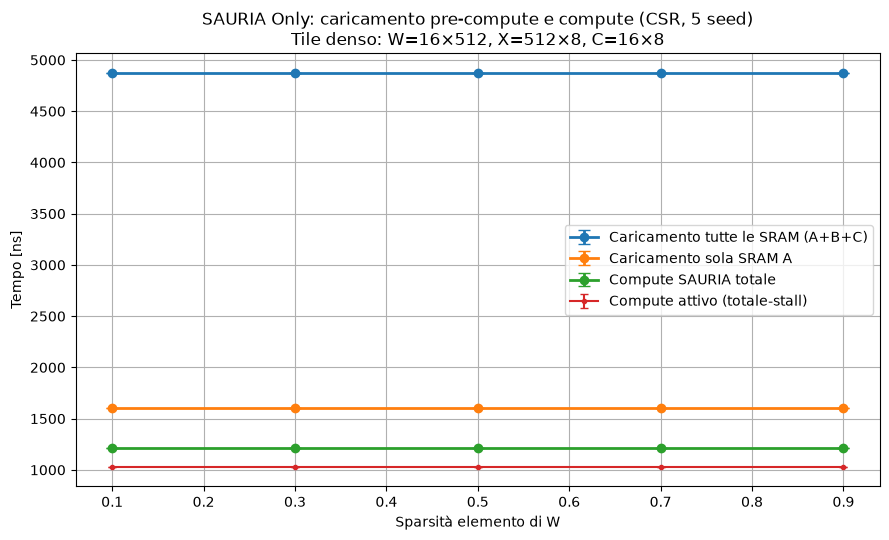

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/requested_phases_sauria_only_csr_union_multiseed.png


In [10]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["target_element_sparsity"]

    plt.errorbar(
        x,
        summary["dense_all_sram_load_ns_mean"],
        yerr=summary["dense_all_sram_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Caricamento tutte le SRAM (A+B+C)",
    )
    plt.errorbar(
        x,
        summary["dense_sram_a_load_ns_mean"],
        yerr=summary["dense_sram_a_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Caricamento sola SRAM A",
    )
    plt.errorbar(
        x,
        summary["dense_compute_ns_mean"],
        yerr=summary["dense_compute_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Compute SAURIA totale",
    )
    plt.errorbar(
        x,
        summary["dense_core_active_ns_mean"],
        yerr=summary["dense_core_active_ns_std"],
        marker=".",
        linewidth=1.5,
        capsize=3,
        label="Compute attivo (totale-stall)",
    )

    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"SAURIA Only: caricamento pre-compute e compute "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"requested_phases_sauria_only_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


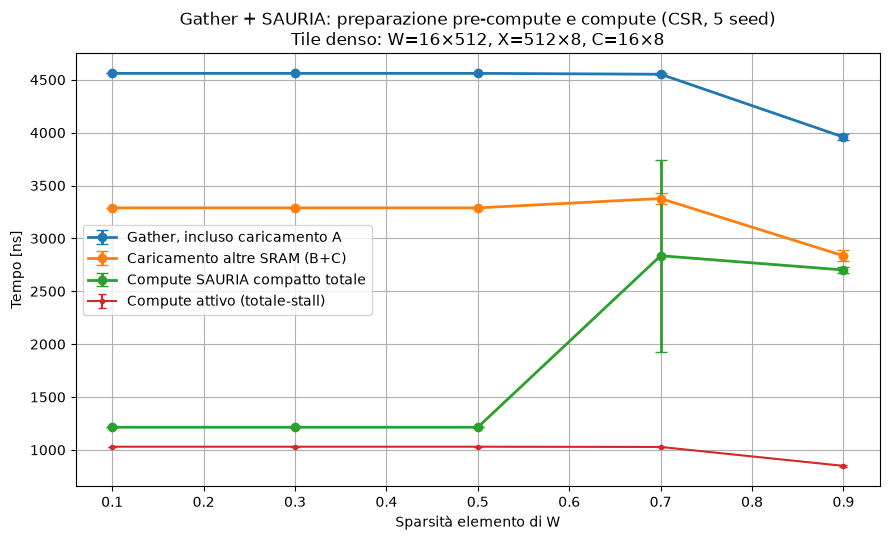

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/requested_phases_gather_sauria_csr_union_multiseed.png


In [11]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["target_element_sparsity"]

    plt.errorbar(
        x,
        summary["gather_unit_ns_mean"],
        yerr=summary["gather_unit_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Gather, incluso caricamento A",
    )
    plt.errorbar(
        x,
        summary["gather_other_sram_load_ns_mean"],
        yerr=summary["gather_other_sram_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Caricamento altre SRAM (B+C)",
    )
    plt.errorbar(
        x,
        summary["gather_compute_ns_mean"],
        yerr=summary["gather_compute_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Compute SAURIA compatto totale",
    )
    plt.errorbar(
        x,
        summary["gather_core_active_ns_mean"],
        yerr=summary["gather_core_active_ns_std"],
        marker=".",
        linewidth=1.5,
        capsize=3,
        label="Compute attivo (totale-stall)",
    )

    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"Gather + SAURIA: preparazione pre-compute e compute "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"requested_phases_gather_sauria_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


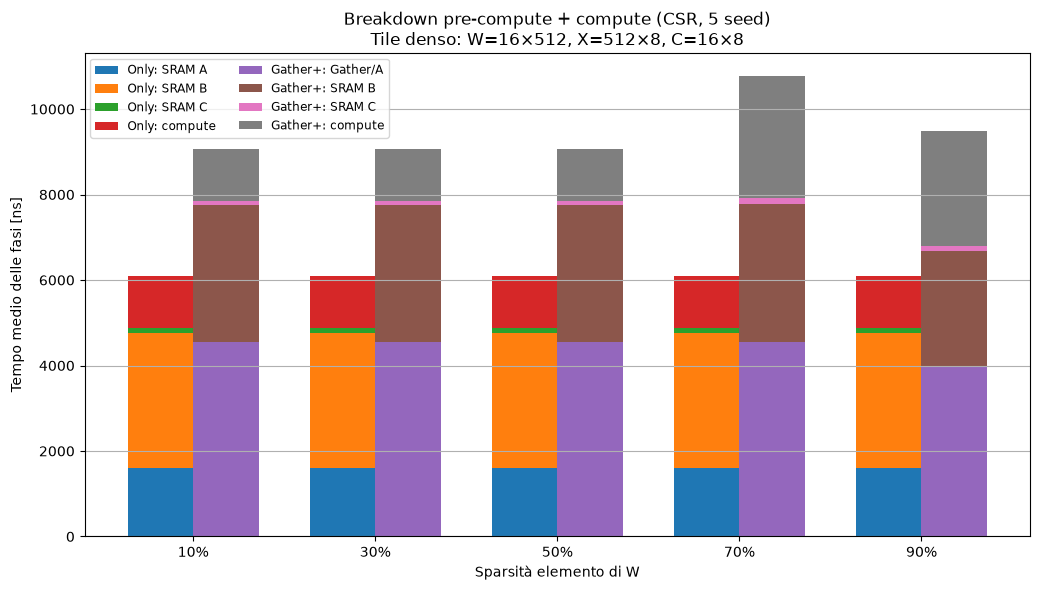

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/phase_breakdown_stacked_csr_union_multiseed.png


In [12]:
if not summary.empty:
    figure = plt.figure(figsize=(10.5, 6.0))

    x = np.arange(len(summary))
    width = 0.36

    dense_a = summary["dense_sram_a_load_ns_mean"].to_numpy()
    dense_b = summary["dense_sram_b_load_ns_mean"].to_numpy()
    dense_c = summary["dense_sram_c_load_ns_mean"].to_numpy()
    dense_compute = summary["dense_compute_ns_mean"].to_numpy()

    gather_unit = summary["gather_unit_ns_mean"].to_numpy()
    gather_b = summary["gather_sram_b_load_ns_mean"].to_numpy()
    gather_c = summary["gather_sram_c_load_ns_mean"].to_numpy()
    gather_compute = summary["gather_compute_ns_mean"].to_numpy()

    plt.bar(x - width / 2, dense_a, width, label="Only: SRAM A")
    plt.bar(
        x - width / 2,
        dense_b,
        width,
        bottom=dense_a,
        label="Only: SRAM B",
    )
    plt.bar(
        x - width / 2,
        dense_c,
        width,
        bottom=dense_a + dense_b,
        label="Only: SRAM C",
    )
    plt.bar(
        x - width / 2,
        dense_compute,
        width,
        bottom=dense_a + dense_b + dense_c,
        label="Only: compute",
    )

    plt.bar(x + width / 2, gather_unit, width, label="Gather+: Gather/A")
    plt.bar(
        x + width / 2,
        gather_b,
        width,
        bottom=gather_unit,
        label="Gather+: SRAM B",
    )
    plt.bar(
        x + width / 2,
        gather_c,
        width,
        bottom=gather_unit + gather_b,
        label="Gather+: SRAM C",
    )
    plt.bar(
        x + width / 2,
        gather_compute,
        width,
        bottom=gather_unit + gather_b + gather_c,
        label="Gather+: compute",
    )

    labels = [
        f"{value:.0%}"
        for value in summary["target_element_sparsity"]
    ]
    plt.xticks(x, labels)
    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Tempo medio delle fasi [ns]")
    plt.title(
        f"Breakdown pre-compute + compute "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True, axis="y")
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"phase_breakdown_stacked_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


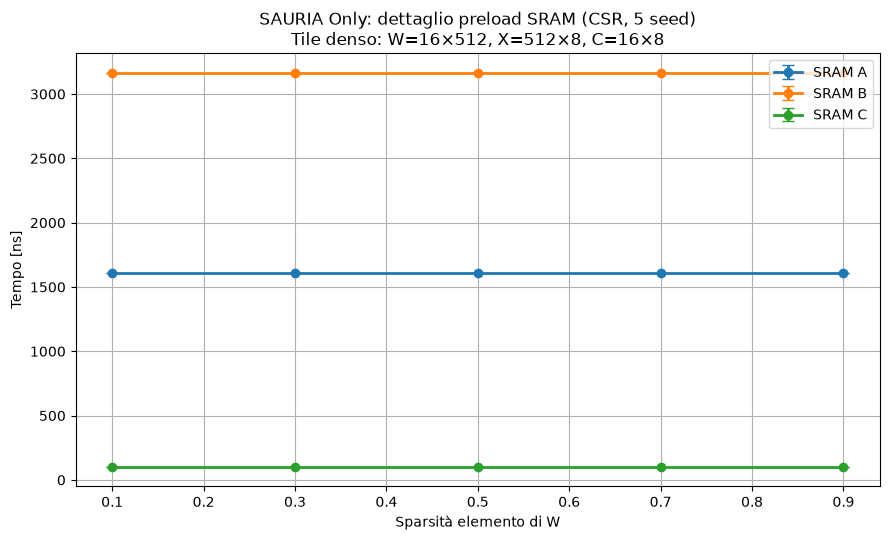

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/sram_detail_sauria_only_csr_union_multiseed.png


In [13]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["target_element_sparsity"]

    for key, label in [
        ("dense_sram_a_load_ns", "SRAM A"),
        ("dense_sram_b_load_ns", "SRAM B"),
        ("dense_sram_c_load_ns", "SRAM C"),
    ]:
        plt.errorbar(
            x,
            summary[f"{key}_mean"],
            yerr=summary[f"{key}_std"],
            marker="o",
            linewidth=2,
            capsize=4,
            label=label,
        )

    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"SAURIA Only: dettaglio preload SRAM "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"sram_detail_sauria_only_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


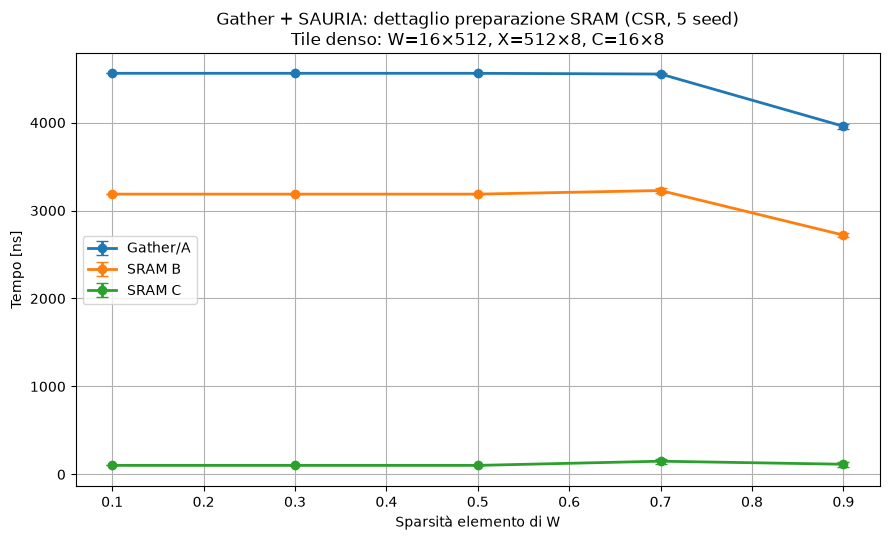

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/sram_detail_gather_sauria_csr_union_multiseed.png


In [14]:
if not summary.empty:
    figure = plt.figure(figsize=(9, 5.5))
    x = summary["target_element_sparsity"]

    plt.errorbar(
        x,
        summary["gather_unit_ns_mean"],
        yerr=summary["gather_unit_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Gather/A",
    )
    plt.errorbar(
        x,
        summary["gather_sram_b_load_ns_mean"],
        yerr=summary["gather_sram_b_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="SRAM B",
    )
    plt.errorbar(
        x,
        summary["gather_sram_c_load_ns_mean"],
        yerr=summary["gather_sram_c_load_ns_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="SRAM C",
    )

    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Tempo [ns]")
    plt.title(
        f"Gather + SAURIA: dettaglio preparazione SRAM "
        f"({SPARSE_FORMAT}, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"sram_detail_gather_sauria_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


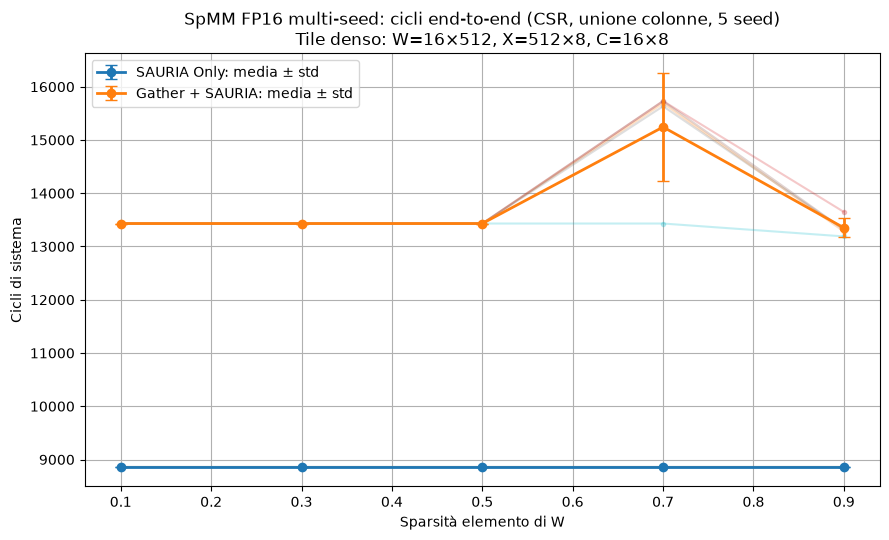

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/cycles_vs_element_sparsity_csr_union_multiseed.png


In [15]:
if not results.empty:
    figure = plt.figure(figsize=(9, 5.5))

    for _, seed_data in results.groupby("seed_index"):
        seed_data = seed_data.sort_values("target_element_sparsity")
        plt.plot(
            seed_data["target_element_sparsity"],
            seed_data["dense_cycles"],
            marker=".",
            alpha=0.25,
        )
        plt.plot(
            seed_data["target_element_sparsity"],
            seed_data["gather_plus_sauria_cycles"],
            marker=".",
            alpha=0.25,
        )

    plt.errorbar(
        summary["target_element_sparsity"],
        summary["dense_cycles_mean"],
        yerr=summary["dense_cycles_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="SAURIA Only: media ± std",
    )
    plt.errorbar(
        summary["target_element_sparsity"],
        summary["gather_cycles_mean"],
        yerr=summary["gather_cycles_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="Gather + SAURIA: media ± std",
    )

    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Cicli di sistema")
    plt.title(
        f"SpMM FP16 multi-seed: cicli end-to-end "
        f"({SPARSE_FORMAT}, unione colonne, {NUM_SEEDS} seed)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"cycles_vs_element_sparsity_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


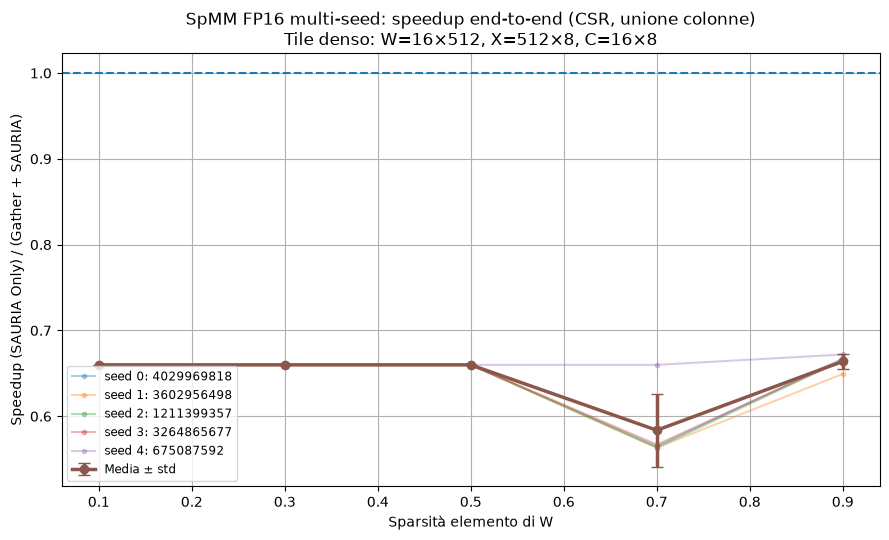

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/speedup_vs_element_sparsity_csr_union_multiseed.png


In [16]:
if not results.empty:
    figure = plt.figure(figsize=(9, 5.5))

    for seed_index, seed_data in results.groupby("seed_index"):
        seed_data = seed_data.sort_values("target_element_sparsity")
        seed_value = int(seed_data["seed"].iloc[0])
        plt.plot(
            seed_data["target_element_sparsity"],
            seed_data["speedup_end_to_end"],
            marker=".",
            alpha=0.35,
            label=f"seed {seed_index}: {seed_value}",
        )

    plt.errorbar(
        summary["target_element_sparsity"],
        summary["speedup_mean"],
        yerr=summary["speedup_std"],
        marker="o",
        linewidth=2.5,
        capsize=4,
        label="Media ± std",
    )
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("Speedup (SAURIA Only) / (Gather + SAURIA)")
    plt.title(
        f"SpMM FP16 multi-seed: speedup end-to-end "
        f"({SPARSE_FORMAT}, unione colonne)\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend(fontsize="small")
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"speedup_vs_element_sparsity_{SPARSE_FORMAT.lower()}_"
        "union_multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


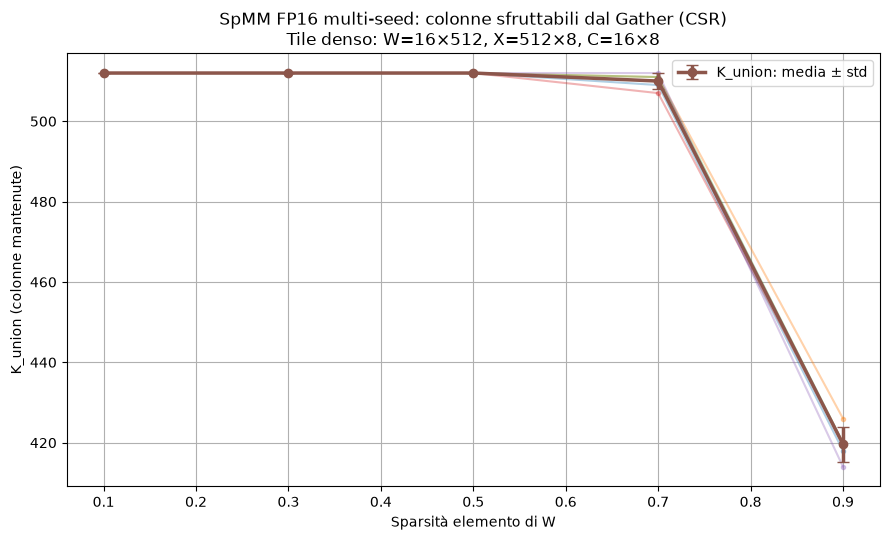

/home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/kunion_vs_element_sparsity_csr_multiseed.png


In [17]:
if not results.empty:
    figure = plt.figure(figsize=(9, 5.5))

    for _, seed_data in results.groupby("seed_index"):
        seed_data = seed_data.sort_values("target_element_sparsity")
        plt.plot(
            seed_data["target_element_sparsity"],
            seed_data["K_union"],
            marker=".",
            alpha=0.35,
        )

    plt.errorbar(
        summary["target_element_sparsity"],
        summary["K_union_mean"],
        yerr=summary["K_union_std"],
        marker="o",
        linewidth=2.5,
        capsize=4,
        label="K_union: media ± std",
    )
    plt.xlabel("Sparsità elemento di W")
    plt.ylabel("K_union (colonne mantenute)")
    plt.title(
        f"SpMM FP16 multi-seed: colonne sfruttabili dal Gather "
        f"({SPARSE_FORMAT})\n"
        f"Tile denso: W={M}×{K}, X={K}×{N}, C={M}×{N}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    path = RESULTS_ROOT / (
        f"kunion_vs_element_sparsity_{SPARSE_FORMAT.lower()}_"
        "multiseed.png"
    )
    figure.savefig(path, dpi=160)
    plt.show()
    print(path)


In [18]:
if not results.empty:
    selected = (
        results
        .sort_values(["target_element_sparsity", "seed_index"])
        .iloc[-1]
    )
    case_root = Path(selected["case_root"])
    print("Seed selezionato:", int(selected["seed"]))
    arrays = np.load(case_root / "operands_and_sparse_formats.npz")

    print("Caso:", case_root)
    print("Shape W_dense:", arrays["W_dense"].shape)
    print("Shape W_compact:", arrays["W_compact"].shape)
    print("Shape X_full:", arrays["X_full"].shape)
    print("Shape X_compact:", arrays["X_compact"].shape)
    print("active_union:", arrays["active_columns"])
    print("Zeri mantenuti in W_compact:", int(np.count_nonzero(arrays["W_compact"] == 0)))
    print("CSR row_ptr:", arrays["csr_row_ptr"])
    print("CSR col_idx, primi 32:", arrays["csr_col_idx"][:32])
    print("CSC col_ptr:", arrays["csc_col_ptr"])
    print("CSC row_idx, primi 32:", arrays["csc_row_idx"][:32])

    print("\nManifest sparse:")
    print((case_root / "sparse_case_manifest.json").read_text())
    print("\nManifest Gather:")
    print((case_root / "gather_stimuli/manifest.json").read_text())


Seed selezionato: 675087592
Caso: /home/henry/sauria/test/spmm_gather_vs_dense_fp16_random_sparsity/seed_04_0675087592/csr_K512_selem0.9000_keff414
Shape W_dense: (16, 512)
Shape W_compact: (16, 414)
Shape X_full: (512, 8)
Shape X_compact: (414, 8)
active_union: [  0   1   4   5   6   7   8   9  10  11  12  14  15  16  18  19  20  21
  23  24  25  26  27  28  29  30  32  33  34  36  37  39  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  57  58  60  61  63  65  66
  68  69  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86
  87  88  89  91  92  93  94  95  98  99 100 101 102 103 104 105 106 107
 108 109 112 113 114 115 116 117 118 119 121 122 123 124 125 126 129 130
 131 132 133 134 135 136 137 138 139 141 143 144 145 147 148 150 152 154
 155 157 158 159 160 161 162 163 165 166 167 169 170 171 172 173 175 176
 177 178 179 180 181 182 183 187 188 189 190 191 192 193 194 195 196 197
 199 200 201 202 204 205 206 207 208 209 210 211 214 215 216 217 218 219
 220 22

## Modifica RTL richiesta

Per ottenere misure esatte dei trasferimenti pre-compute è necessario aggiungere
il modulo simulativo `sauria_phase_monitor.sv`.

Il modulo:

- osserva il primo handshake AXI AW del DMA verso le regioni SRAM A, B e C;
- associa il successivo interrupt del writer DMA alla fine del trasferimento;
- misura il Gather dal fronte di salita di `gather_busy` a `gather_doneintr`;
- osserva `sauria_intr2control` e ignora nuovi trasferimenti dopo il completamento
  del core, evitando di contare il writeback finale di C;
- è racchiuso in `` `ifndef SYNTHESIS `` e non modifica il datapath sintetizzato.

Marker prodotti:

```text
[PERF_PHASE] phase=SRAM_A_LOAD event=START cycle=...
[PERF_PHASE] phase=SRAM_A_LOAD event=DONE  cycle=...
[PERF_PHASE] phase=SRAM_B_LOAD event=START cycle=...
[PERF_PHASE] phase=SRAM_B_LOAD event=DONE  cycle=...
[PERF_PHASE] phase=SRAM_C_LOAD event=START cycle=...
[PERF_PHASE] phase=SRAM_C_LOAD event=DONE  cycle=...
[PERF_PHASE] phase=GATHER event=START cycle=...
[PERF_PHASE] phase=GATHER event=DONE  cycle=...
```

Copiare il modulo in `RTL/src`, aggiungerlo a `RTL/filelist.f` e istanziarlo nel
subsystem seguendo il file `SAURIA_PHASE_MONITOR_INTEGRATION.md`.


## Interpretazione

La somma delle durate A+B+C o B+C rappresenta il tempo occupato dai trasferimenti
DMA veri e propri. Non include gli intervalli di configurazione del controller tra
un trasferimento e il successivo; tali overhead restano inclusi nel tempo
end-to-end.

`compute totale` è il contatore del core letto a `0x50000014`.
`compute attivo` è calcolato come `compute totale - stall`, usando il contatore
`0x50000018`.

Il CSV completo conserva ogni run e ogni fase. Il CSV aggregato riporta media e
deviazione standard per livello di sparsità.
